# Analyse empirique de la relation entre les métaux précieux et les conditions macro-financières

# PARTIE I. Modèle bi-varié 

## 1. Introduction et objectif économétrique

Ce projet étudie la relation de long terme entre les prix de l'or et de l'argent sur la période 2000–2024.

**Question de recherche** : les prix de l'or et de l'argent partagent-ils toujours une relation d'équilibre de long terme, ou cette relation dépend -t-elle du régime économique?

**Hypothèse centrale** : la relation bilatérale or–argent est instable sur l'ensemble de la période. Elle se manifeste par épisodes, sous l'influence de facteurs macrofinanciers, en particulier le dollar américain (DXY) et les taux longs US (US10Y).

**Extension** : une fois le cadre bivarié or–argent établi, l'analyse est étendue à un système multivarié intégrant le dollar index (DXY) et le taux à 10 ans américain (US10Y) afin de tester si la cointégration est plus stable une fois les facteurs macro ajoutés.

**Méthodes mobilisées** : tests ADF/KPSS, Engle-Granger, Johansen, rolling cointegration, modélisation VAR, VECM, IRF, FEVD, causalité de Granger.

## 2. Données et préparation

### 2.1 Importation des bibliothèques

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np        
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf

from IPython.display import display, Markdown
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen

### 2.2 Fonctions utilitaires

In [3]:
def adf_test(series, regression="ct"):
    stat, pvalue, usedlag, nobs, crit, icbest = adfuller(
        series.dropna(), regression=regression, autolag="AIC")
    return {
        "ADF stat": stat,
        "p-value": pvalue,
        "retards": usedlag,
        "crit_5%": crit["5%"]}

def kpss_test(series, regression="c"):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        stat, pvalue, lags, crit = kpss(
            series.dropna(), regression=regression, nlags="auto")
    return {
        "KPSS stat": stat,
        "p-value KPSS": pvalue,
        "lags": lags,
        "crit_5%": crit["5%"]}

def stationarity_table(data):
    rows = []
    for col in data.columns:
        adf_res = adf_test(data[col], regression="n")
        kpss_res = kpss_test(data[col], regression="c")

        rows.append({
            "Série": col,
            "ADF stat": adf_res["ADF stat"],
            "ADF p-value": adf_res["p-value"],
            "ADF conclusion": "Stationnaire" if adf_res["p-value"] < 0.05 else "Non stationnaire",
            "KPSS stat": kpss_res["KPSS stat"],
            "KPSS p-value": kpss_res["p-value KPSS"],
            "KPSS conclusion": "Non stationnaire" if kpss_res["p-value KPSS"] < 0.05 else "Stationnaire" })
    return pd.DataFrame(rows).set_index("Série")

def mco_methode(sample):
    x = sample["log_silver"]
    y = sample["log_gold"]

    beta_hat = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum()
    alpha_hat = y.mean() - beta_hat * x.mean()
    u_hat = y - alpha_hat - beta_hat * x

    adf_res = adf_test(u_hat, regression="c")

    return alpha_hat, beta_hat, u_hat, adf_res

def johansen_all_specs(
    data,
    variables=["log_gold", "log_silver"],
    det_orders=(0, 1),
    k_ar_diffs=(0, 1, 2),
    signif_index=1):
    results = []

    if isinstance(data, dict):
        data_dict = data
    else:
        data_dict = {"Global": data}

    for label, df_raw in data_dict.items():
        df = df_raw[variables].dropna()
        for det_order in det_orders:
            for k_ar_diff in k_ar_diffs:
                joh = coint_johansen(
                    df,
                    det_order=det_order,
                    k_ar_diff=k_ar_diff)
                rank = 0

                for i in range(len(joh.lr1)):
                    trace_stat = joh.lr1[i]
                    crit_value = joh.cvt[i, signif_index]
                    if trace_stat > crit_value:
                        rank = i + 1
                    else:
                        break

                if rank == 0:
                    conclusion = "Pas de cointégration"
                elif rank == 1:
                    conclusion = "Une relation de cointégration"
                else:
                    conclusion = f"{rank} relations de cointégration"

                results.append({
                    "Période": label,
                    "det_order": det_order,
                    "k_ar_diff": k_ar_diff,
                    "Trace r<=0": round(joh.lr1[0], 4),
                    "Crit 5% r<=0": round(joh.cvt[0, signif_index], 4),
                    "Décision r<=0": (
                        "Rejet H0" if joh.lr1[0] > joh.cvt[0, signif_index]
                        else "Non-rejet H0"),
                    "Trace r<=1": round(joh.lr1[1], 4),
                    "Crit 5% r<=1": round(joh.cvt[1, signif_index], 4),
                    "Décision r<=1": (
                        "Rejet H0" if joh.lr1[1] > joh.cvt[1, signif_index]
                        else "Non-rejet H0"),
                    "Rang retenu": rank,
                    "Conclusion": conclusion
                })

    return pd.DataFrame(results)

def level_metrics(pred, actual):
    err = pred - actual
    rows = []
    for col in pred.columns:
        rows.append({
            "Variable" : col,
            "RMSE" : np.sqrt((err[col] ** 2).mean()),
            "MAE" : err[col].abs().mean(),
            "MAPE_%" : (err[col].abs() / actual[col].abs()).mean() * 100 })
    return pd.DataFrame(rows).set_index("Variable")

def recursive_one_step_forecast(diff_df, log_df, start_idx, end_idx, p):
    pred_diff, act_diff, pred_log, act_log = [], [], [], []
    idx = []

    for t in range(start_idx, end_idx):
        history = diff_df.iloc[:t]
        model = VAR(history).fit(p)
        fc = model.forecast(history.values[-p:], steps=1)[0]

        date = diff_df.index[t]
        prev_log = log_df.loc[diff_df.index[t-1]].values

        pred_diff.append(fc)
        act_diff.append(diff_df.iloc[t].values)
        pred_log.append(prev_log + fc)
        act_log.append(log_df.loc[date].values)
        idx.append(date)

    pred_diff = pd.DataFrame(pred_diff, index=idx, columns=diff_df.columns)
    act_diff = pd.DataFrame(act_diff, index=idx, columns=diff_df.columns)
    pred_log = pd.DataFrame(pred_log, index=idx, columns=log_df.columns)
    act_log = pd.DataFrame(act_log, index=idx, columns=log_df.columns)

    return pred_diff, act_diff, pred_log, act_log

### 2.3 Téléchargement des données or et argent

In [4]:
gold = yf.download("GC=F", start="2000-01-01", end="2024-12-31")["Close"]
silver = yf.download("SI=F", start="2000-01-01", end="2024-12-31")["Close"] 

df_raw = pd.concat([gold, silver], axis=1)
df_raw.columns = ["gold", "silver"] 

print("Nombre d'observations initiales :", len(df_raw))
print("\nValeurs manquantes avant imputation :")
print(df_raw.isna().sum())
print("\nPourcentage de NaN :")
print((df_raw.isna().sum() / len(df_raw) * 100).round(3), "%")

df_raw.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Nombre d'observations initiales : 6108

Valeurs manquantes avant imputation :
gold      3
silver    1
dtype: int64

Pourcentage de NaN :
gold      0.049
silver    0.016
dtype: float64 %


,gold,silver
Date,,
2000-08-30,273.899994,4.930
2000-08-31,278.299988,5.003
2000-09-01,277.000000,5.004
2000-09-05,275.799988,4.998
2000-09-06,274.200012,4.983


In [5]:
df_raw.tail()

,gold,silver
Date,,
2024-12-23,2612.300049,29.888000
2024-12-24,2620.000000,29.974001
2024-12-26,2638.800049,30.047001
2024-12-27,2617.199951,29.655001
2024-12-30,2606.100098,29.106001


### 2.4 Imputation des valeurs manquantes

Les données de prix téléchargées via `yfinance` présentent un très faible taux de valeurs manquantes : 241 observations ne sont pas disponibles sur la période étudiée. Les séries ne suivent donc pas parfaitement un calendrier uniforme de type business days. 
Nous avons choisi de conserver les données brutes sans réindexer artificiellement la base sur l’ensemble des jours ouvrés car une telle réindexation aurait créé des observations inexistantes dans la source initiale et aurait nécessité davantage d’imputations. Cela risquerait d’introduire une structure artificielle dans les séries notamment en raison des jours fériés, des fermetures de marché ou des différences de calendrier de cotation entre l’or et l’argent, ce qui aurait pu modifier la dynamique temporelle des données et biaiser les tests économétriques.

On a testé

- **Forward fill (ffill)** : qui consiste à remplacer chaque valeur par la dernière valeur observée : cette méthode ne mobilise aucune information future et évite donc tout look-ahead bias.
- **Interpolation linéaire** : où chaque valeur manquante est estimé par interpolation entre la valeur précédente et la suivante.

Les deux approches conduisent à des séries très proches et n’affectent pas significativement les propriétés statistiques des données. Le ffill a néanmoins été retenu car il respecte davantage la causalité temporelle en n’utilisant que l’information disponible à la date considérée.

In [6]:
df_ffill = df_raw.ffill()

print("\nValeurs manquantes après ffill :")
print(df_ffill.isna().sum())

df_ffill.head()


Valeurs manquantes après ffill :
gold      0
silver    0
dtype: int64


,gold,silver
Date,,
2000-08-30,273.899994,4.930
2000-08-31,278.299988,5.003
2000-09-01,277.000000,5.004
2000-09-05,275.799988,4.998
2000-09-06,274.200012,4.983


In [7]:
df_interp = df_raw.interpolate(method="linear")

print("Valeurs manquantes après interpolation :")
print(df_interp.isna().sum())

df_interp.head()

Valeurs manquantes après interpolation :
gold      0
silver    0
dtype: int64


,gold,silver
Date,,
2000-08-30,273.899994,4.930
2000-08-31,278.299988,5.003
2000-09-01,277.000000,5.004
2000-09-05,275.799988,4.998
2000-09-06,274.200012,4.983


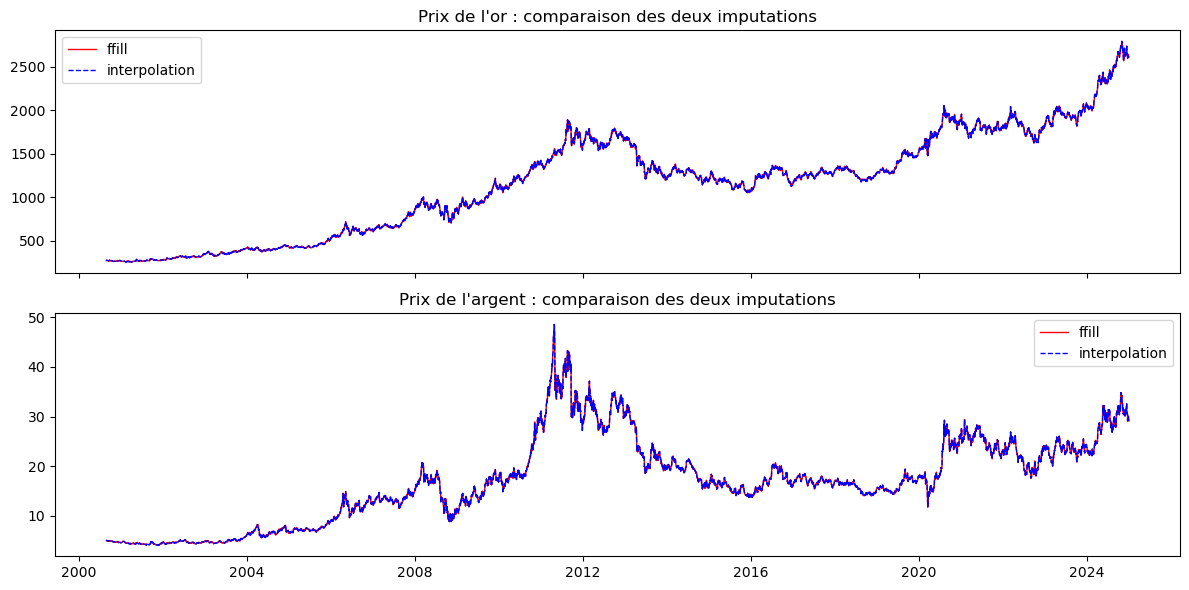

In [7]:
# Comparaison des deux méthodes d'imputation
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_ffill["gold"], label="ffill", linewidth=1, color="red")
axes[0].plot(df_interp["gold"],label="interpolation", linewidth=1, color="blue", linestyle="--")
axes[0].set_title("Prix de l'or : comparaison des deux imputations")
axes[0].legend()

axes[1].plot(df_ffill["silver"], label="ffill", linewidth=1, color="red")
axes[1].plot(df_interp["silver"],label="interpolation", linewidth=1, color="blue", linestyle="--")
axes[1].set_title("Prix de l'argent : comparaison des deux imputations")
axes[1].legend()

plt.tight_layout()
plt.show()

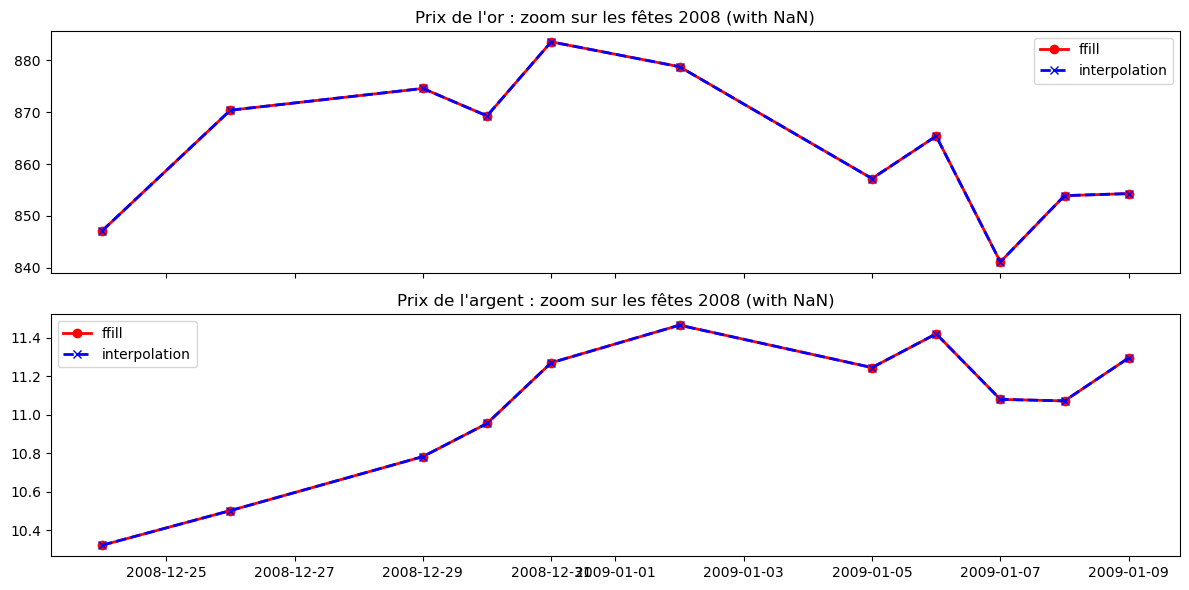

In [8]:
# on zoome sur une petite fenêtre 
debut = "2008-12-24" # période de fêtes (plus de jours fériés donc plus de NaN)
fin = "2009-01-10"

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_ffill["gold"][debut:fin], label="ffill", linewidth=2, color="red",  marker="o")
axes[0].plot(df_interp["gold"][debut:fin], label="interpolation", linewidth=2, color="blue", marker="x", linestyle="--")
axes[0].set_title("Prix de l'or : zoom sur les fêtes 2008 (with NaN)")
axes[0].legend()

axes[1].plot(df_ffill["silver"][debut:fin], label="ffill", linewidth=2, color="red",  marker="o")
axes[1].plot(df_interp["silver"][debut:fin], label="interpolation", linewidth=2, color="blue", marker="x", linestyle="--")
axes[1].set_title("Prix de l'argent : zoom sur les fêtes 2008 (with NaN)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
df = df_ffill.copy()  

print(f"Dimensions finales : {df.shape}") 
print("\nNaN restants :")
print(df.isna().sum())

df_raw.head()

Dimensions finales : (6108, 2)

NaN restants :
gold      0
silver    0
dtype: int64


,gold,silver
Date,,
2000-08-30,273.899994,4.930
2000-08-31,278.299988,5.003
2000-09-01,277.000000,5.004
2000-09-05,275.799988,4.998
2000-09-06,274.200012,4.983


### 2.5 Transformations : log-prix, log-ratio et rendements

Les prix bruts sont transformés en log-prix afin de stabiliser la variance des séries et de linéariser les relations entre les variables. 

Le log-ratio défini comme la différence entre les log-prix de l’or et de l’argent mesure l’écart relatif entre les deux métaux et permet d’étudier leur relation de long terme. 

Les différences premières des log-prix correspondent aux rendements logarithmiques des actifs et sont utilisées pour analyser la dynamique de court terme des séries car elles présentent généralement de meilleures propriétés statistiques notamment en termes de stationnarité.

In [10]:
df["log_gold"] = np.log(df["gold"])
df["log_silver"] = np.log(df["silver"])

# Log-ratio (spread) : log(gold) - log(silver) = log(gold/silver)
df["log_ratio"] = df["log_gold"] - df["log_silver"]

# Rendements (différences)
df["dlog_gold"] = df["log_gold"].diff()
df["dlog_silver"] = df["log_silver"].diff()

df

,gold,silver,log_gold,log_silver,log_ratio,dlog_gold,dlog_silver
Date,,,,,,,
2000-08-30,273.899994,4.930000,5.612763,1.595339,4.017424,NaN,NaN
2000-08-31,278.299988,5.003000,5.628700,1.610038,4.018662,0.015937,0.014699
2000-09-01,277.000000,5.004000,5.624018,1.610238,4.013780,-0.004682,0.000200
2000-09-05,275.799988,4.998000,5.619676,1.609038,4.010638,-0.004342,-0.001200
2000-09-06,274.200012,4.983000,5.613858,1.606032,4.007826,-0.005818,-0.003006
...,...,...,...,...,...,...,...
2024-12-23,2612.300049,29.888000,7.867986,3.397457,4.470529,-0.006258,0.007658
2024-12-24,2620.000000,29.974001,7.870930,3.400330,4.470599,0.002943,0.002873
2024-12-26,2638.800049,30.047001,7.878080,3.402763,4.475317,0.007150,0.002432


## 3. Analyse descriptive

### 3.1 Graphiques des log-prix et du log-ratio

Le log-ratio Or/Argent mesure la valeur relative de l'or par rapport à l'argent. Une hausse indique que l'or surperforme l'argent, une baisse l'inverse. 
Cette transformation permet d'obtenir un spread relatif plus stable (sur le long terme) et mieux adapté aux analyses de cointégration.

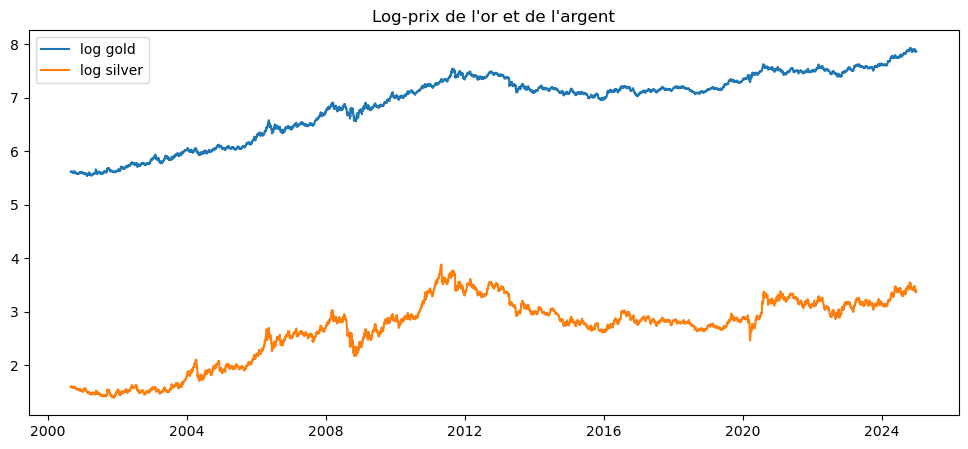

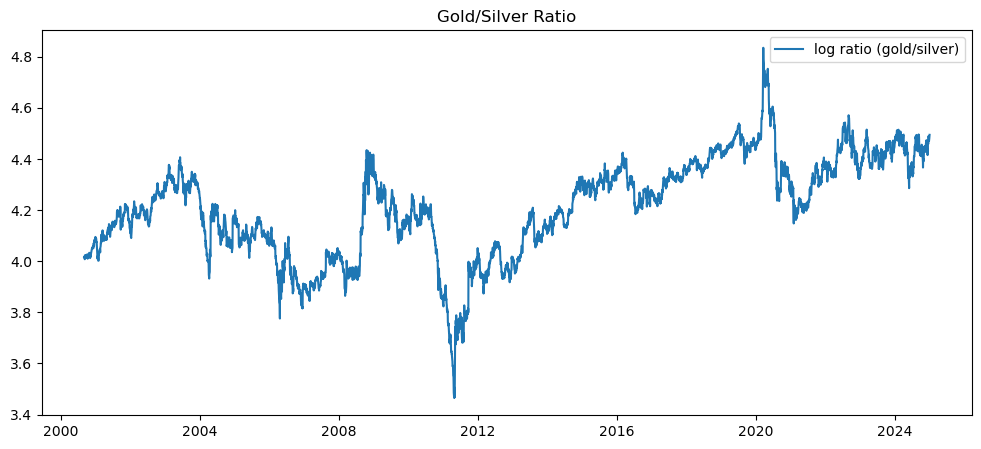

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["log_gold"], label="log gold")
plt.plot(df.index, df["log_silver"], label="log silver")
plt.title("Log-prix de l'or et de l'argent")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["log_ratio"], label="log ratio (gold/silver)")
plt.title("Gold/Silver Ratio")
plt.legend()
plt.show()

In [12]:
stat_desc = df[["gold", "silver","log_gold", "log_silver", "log_ratio"]].describe()
print(stat_desc)

              gold       silver     log_gold   log_silver    log_ratio
count  6108.000000  6108.000000  6108.000000  6108.000000  6108.000000
mean   1160.466552    17.044065     6.888745     2.680254     4.208490
std     580.349448     8.498464     0.633132     0.603416     0.192802
min     255.100006     4.026000     5.541656     1.392773     3.465582
25%     630.375000    11.478750     6.446315     2.440497     4.078893
50%    1233.700012    16.747000     7.117773     2.818219     4.218857
75%    1615.199951    22.680501     7.387214     3.121506     4.352910
max    2788.500000    48.584000     7.933259     3.883294     4.835396


In [13]:
higher_moments = pd.DataFrame({
    "skewness": df[["gold", "silver","log_gold", "log_silver", "log_ratio"]].skew(),
    "kurtosis": df[["gold", "silver","log_gold", "log_silver", "log_ratio"]].kurtosis()})

print(higher_moments)

            skewness  kurtosis
gold        0.100156 -0.718724
silver      0.375349 -0.226261
log_gold   -0.733237 -0.703122
log_silver -0.713359 -0.464713
log_ratio  -0.342492 -0.013322


## 4. Découpage de l'échantillon

L'échantillon est découpé en trois sous-périodes selon une règle 70/15/15 :

- **Apprentissage (70%)** : estimation des modèles et sélection des hyperparamètres.
- **Validation (15%)** : choix du nombre de retards du VAR par prévision récursive hors échantillon.
- **Test (15%)** : évaluation finale des performances prédictives.

In [14]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()

split_table = pd.DataFrame({
    "Sous-échantillon": ["Apprentissage", "Validation", "Test"],
    "Début": [df_train.index.min().date(), df_val.index.min().date(), df_test.index.min().date()],
    "Fin": [df_train.index.max().date(), df_val.index.max().date(), df_test.index.max().date()],
    "Nombre d'observations": [len(df_train), len(df_val), len(df_test)]})

display(split_table)

,Sous-échantillon,Début,Fin,Nombre d'observations
0,Apprentissage,2000-08-30,2017-09-14,4275
1,Validation,2017-09-15,2021-05-07,916
2,Test,2021-05-10,2024-12-30,917


## 5. Tests de stationnarité

Les tests ADF (Augmented Dickey-Fuller) et KPSS (Kwiatkowski-Phillips-Schmidt-Shin) sont appliqués en niveau et en différences premières sur l'échantillon d'apprentissage. Ces deux tests sont complémentaires : l'ADF teste H0 = racine unitaire, le KPSS teste H0 = stationnarité. La convergence des deux conclusions renforce la robustesse du diagnostic.

### 5.1 Tests en niveau

In [15]:
level_table = stationarity_table(df_train[["log_gold", "log_silver", "log_ratio"]])
level_table

,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,2.124696,0.993220,Non stationnaire,9.403189,0.01,Non stationnaire
log_silver,0.579998,0.842608,Non stationnaire,7.995662,0.01,Non stationnaire
log_ratio,0.273206,0.767535,Non stationnaire,1.121314,0.01,Non stationnaire


### 5.2 Tests en différences premières

In [15]:
diff_table = stationarity_table(df_train[["dlog_gold", "dlog_silver"]])
diff_table

,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
dlog_gold,-20.829609,0.0,Stationnaire,0.243067,0.1,Stationnaire
dlog_silver,-66.684309,0.0,Stationnaire,0.149876,0.1,Stationnaire


### 5.3 Nettoyage avant estimation VAR

L'opération `.diff()` introduit mécaniquement un NaN à la première ligne. Ce NaN est supprimé avant toute estimation car le VAR ne tolère pas les valeurs manquantes.

In [16]:
train_diff = df_train[["dlog_gold", "dlog_silver"]]
train_diff_clean = train_diff.replace([np.inf, -np.inf], np.nan).dropna().copy()

sel_train = VAR(train_diff_clean).select_order(maxlags=10, trend="c")
sel_train.summary()

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-17.69*,-17.69*,2.078e-08*,-17.69*
1,-17.69,-17.68,2.080e-08,-17.69
2,-17.69,-17.67,2.078e-08,-17.68
3,-17.69,-17.67,2.082e-08,-17.68
4,-17.69,-17.66,2.082e-08,-17.68
5,-17.69,-17.65,2.084e-08,-17.67
6,-17.69,-17.65,2.081e-08,-17.67
7,-17.69,-17.64,2.082e-08,-17.67
8,-17.69,-17.64,2.080e-08,-17.67
9,-17.69,-17.63,2.082e-08,-17.67


## 6. Analyse de cointégration bivariée or-argent

### 6.1 Logique prédictive

Les tests de racine unitaire indiquent que les log-prix de l’or et de l’argent ne sont pas stationnaires en niveau tandis que leurs différences premières le deviennent. Les séries sont donc intégrées d’ordre un, I(1), condition nécessaire à la mise en œuvre des tests de cointégration.

La cointégration permet de vérifier si une combinaison linéaire de deux séries non stationnaires est elle-même stationnaire ce qui traduirait l’existence d’une relation d’équilibre de long terme entre les deux actifs. 

Le test d’Engle-Granger est ainsi appliqué aux séries log_gold et log_silver sur l’échantillon d’apprentissage. Cette approche consiste à estimer une relation de long terme entre les deux séries puis à tester la stationnarité des résidus obtenus. L’hypothèse nulle correspond à l’absence de cointégration entre les variables.

In [17]:
from statsmodels.tsa.stattools import coint

data_eg = df_train[["log_gold", "log_silver"]].replace([np.inf, -np.inf], np.nan).dropna()

score, pvalue, crit = coint(data_eg["log_gold"],data_eg["log_silver"])

eg_result = pd.DataFrame([{
    "Méthode": "Engle-Granger",
    "Hypothèse nulle": "Absence de cointégration",
    "Statistique": round(score, 4),
    "p-value": round(pvalue, 4),
    "Seuil critique 1%": round(crit[0], 4),
    "Seuil critique 5%": round(crit[1], 4),
    "Seuil critique 10%": round(crit[2], 4),
    "Décision": "Rejet H0" if pvalue < 0.05 else "Non-rejet H0",
    "Conclusion": "Cointégration" if pvalue < 0.05 else "Pas de cointégration"
}])

display(eg_result)

,Méthode,Hypothèse nulle,Statistique,p-value,Seuil critique 1%,Seuil critique 5%,Seuil critique 10%,Décision,Conclusion
0,Engle-Granger,Absence de cointégration,-2.543,0.2604,-3.899,-3.3376,-3.0454,Non-rejet H0,Pas de cointégration


Le test de Johansen est appliqué selon plusieurs spécifications afin d’évaluer la robustesse des résultats de cointégration.

In [18]:
johansen_global_specs = johansen_all_specs(
    data = df_train,
    variables=["log_gold", "log_silver"],
    det_orders=(0, 1),
    k_ar_diffs=(0, 1, 2),
    signif_index=1
)

display(johansen_global_specs)

,Période,det_order,k_ar_diff,Trace r<=0,Crit 5% r<=0,Décision r<=0,Trace r<=1,Crit 5% r<=1,Décision r<=1,Rang retenu,Conclusion
0,Global,0,0,8.4978,15.4943,Non-rejet H0,0.1004,3.8415,Non-rejet H0,0,Pas de cointégration
1,Global,0,1,9.1640,15.4943,Non-rejet H0,2.1535,3.8415,Non-rejet H0,0,Pas de cointégration
2,Global,0,2,9.6934,15.4943,Non-rejet H0,2.1628,3.8415,Non-rejet H0,0,Pas de cointégration
3,Global,1,0,16.2677,18.3985,Non-rejet H0,3.6559,3.8415,Non-rejet H0,0,Pas de cointégration
4,Global,1,1,13.8888,18.3985,Non-rejet H0,1.0532,3.8415,Non-rejet H0,0,Pas de cointégration
5,Global,1,2,14.2981,18.3985,Non-rejet H0,1.0303,3.8415,Non-rejet H0,0,Pas de cointégration


### 6.2 Analyse complémentaire de stabilité
#### Instabilité temporelle : Test de Johansen par sous-périodes 
En complément de l’analyse principale réalisée sur l’échantillon d’apprentissage, une analyse par sous-périodes est menée sur l’ensemble de l’échantillon afin d’étudier la stabilité temporelle de la relation entre l’or et l’argent selon différents régimes économiques. Cette analyse n’est pas utilisée pour calibrer le modèle prédictif, mais sert à interpréter les éventuelles variations de la relation de long terme.

In [19]:
print("Début df_train :", df_train.index.min())
print("Fin df_train :", df_train.index.max())

Début df_train : 2000-08-30 00:00:00
Fin df_train : 2017-09-14 00:00:00


In [20]:
periods = {
    "pre_crisis_global" : df.loc["2000":"2007-06"],
    "global_financial_crisis": df.loc["2007-07":"2009"],
    "post_crisis_QE" : df.loc["2010":"2014"],
    "commodity_stress" : df.loc["2015":"2016"],
    "late_cycle_expansion" : df.loc["2017":"2019"],
    "covid_shock" : df.loc["2020":"2022"],
}
johansen_period_specs = johansen_all_specs(
    data=periods,
    variables=["log_gold", "log_silver"],
    det_orders=(0, 1),
    k_ar_diffs=(0, 1, 2),
    signif_index=1 )

display(johansen_period_specs)

,Période,det_order,k_ar_diff,Trace r<=0,Crit 5% r<=0,Décision r<=0,Trace r<=1,Crit 5% r<=1,Décision r<=1,Rang retenu,Conclusion
0,pre_crisis_global,0,0,5.8528,15.4943,Non-rejet H0,1.3580,3.8415,Non-rejet H0,0,Pas de cointégration
1,pre_crisis_global,0,1,8.2119,15.4943,Non-rejet H0,0.0686,3.8415,Non-rejet H0,0,Pas de cointégration
2,pre_crisis_global,0,2,8.8562,15.4943,Non-rejet H0,0.0931,3.8415,Non-rejet H0,0,Pas de cointégration
3,pre_crisis_global,1,0,16.6326,18.3985,Non-rejet H0,3.0737,3.8415,Non-rejet H0,0,Pas de cointégration
4,pre_crisis_global,1,1,21.3012,18.3985,Rejet H0,7.4054,3.8415,Rejet H0,2,2 relations de cointégration
5,pre_crisis_global,1,2,22.4421,18.3985,Rejet H0,7.9910,3.8415,Rejet H0,2,2 relations de cointégration
6,global_financial_crisis,0,0,5.0404,15.4943,Non-rejet H0,0.4891,3.8415,Non-rejet H0,0,Pas de cointégration
7,global_financial_crisis,0,1,7.5806,15.4943,Non-rejet H0,2.5902,3.8415,Non-rejet H0,0,Pas de cointégration
8,global_financial_crisis,0,2,6.8482,15.4943,Non-rejet H0,2.5920,3.8415,Non-rejet H0,0,Pas de cointégration
9,global_financial_crisis,1,0,13.8570,18.3985,Non-rejet H0,4.2098,3.8415,Rejet H0,0,Pas de cointégration


#### Rolling Engle-Granger

Une approche rolling du test d’Engle-Granger est ensuite utilisée afin d’analyser la stabilité temporelle de la relation de cointégration entre l’or et l’argent. 
Le test est appliqué sur des fenêtres glissantes de 1000 observations. Pour chaque fenêtre, la p-value du test est conservée ce qui permet d’identifier les périodes durant lesquelles l’hypothèse nulle d’absence de cointégration est rejetée. 
Les zones colorées correspondent aux intervalles où la p-value reste inférieure à 5 % pendant plus de 60 jours signalant une relation de long terme temporairement significative.

In [21]:
window = 1000

cointeg_df = (
    df[["log_gold", "log_silver"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

rows = []

for i in range(window, len(cointeg_df)):
    sub = cointeg_df.iloc[i-window:i]

    score, pvalue, crit = coint(
        sub["log_gold"],
        sub["log_silver"])

    rows.append({
        "Date": cointeg_df.index[i],
        "Statistique EG": score,
        "p-value": pvalue,
        "Seuil critique 1%": crit[0],
        "Seuil critique 5%": crit[1],
        "Seuil critique 10%": crit[2],
        "Décision": "Rejet H0" if pvalue < 0.05 else "Non-rejet H0",
        "Conclusion": "Cointégration" if pvalue < 0.05 else "Pas de cointégration"})

rolling_eg = pd.DataFrame(rows).set_index("Date")

rolling_eg.head()

,Statistique EG,p-value,Seuil critique 1%,Seuil critique 5%,Seuil critique 10%,Décision,Conclusion
Date,,,,,,,
2004-09-03,-2.009089,0.523851,-3.907436,-3.342253,-3.048698,Non-rejet H0,Pas de cointégration
2004-09-07,-2.005764,0.525580,-3.907436,-3.342253,-3.048698,Non-rejet H0,Pas de cointégration
2004-09-08,-2.054860,0.499969,-3.907436,-3.342253,-3.048698,Non-rejet H0,Pas de cointégration
2004-09-09,-2.075648,0.489101,-3.907436,-3.342253,-3.048698,Non-rejet H0,Pas de cointégration
2004-09-10,-2.100719,0.475991,-3.907436,-3.342253,-3.048698,Non-rejet H0,Pas de cointégration


In [22]:
intervals = []

mask = rolling_eg["p-value"] < 0.05
start = None

for date, val in mask.items():
    if val and start is None:
        start = date
    elif not val and start is not None:
        intervals.append((start, date))
        start = None

if start is not None:
    intervals.append((start, rolling_eg.index[-1]))

intervals_filtered = [
    (s, e)
    for (s, e) in intervals
    if (e - s).days > 60]

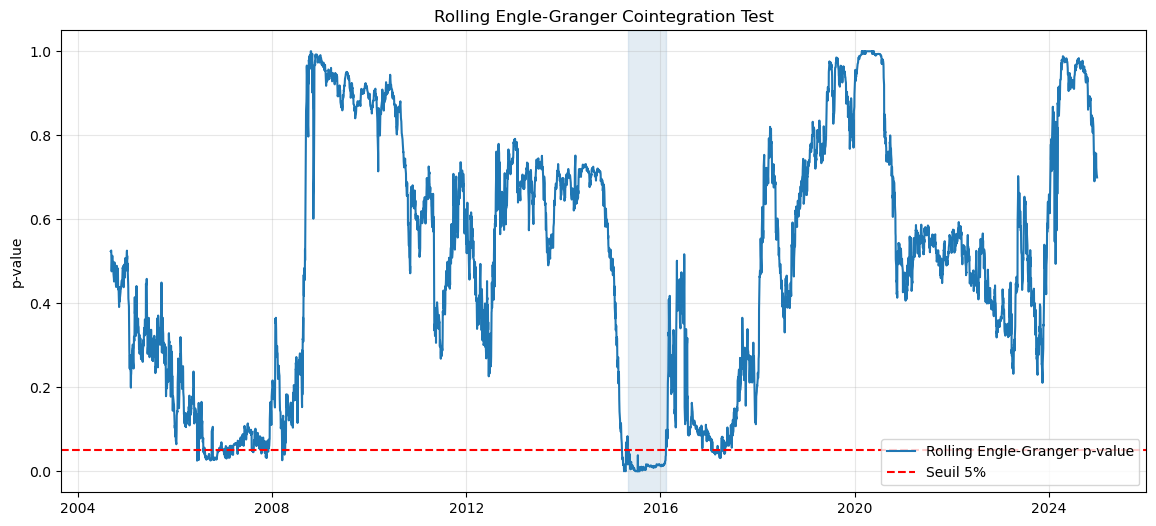

In [23]:
plt.figure(figsize=(14,6))

plt.plot(
    rolling_eg.index,
    rolling_eg["p-value"],
    label="Rolling Engle-Granger p-value")

plt.axhline(
    0.05,
    linestyle="--",
    color="red",
    label="Seuil 5%")

for (s, e) in intervals_filtered:
    plt.axvspan(s, e, alpha=0.15, color="steelblue")

plt.title("Rolling Engle-Granger Cointegration Test")
plt.ylabel("p-value")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

Robustesse mensuelle : test de Johansen 

Une analyse de robustesse est également menée sur des données agrégées à fréquence mensuelle afin d’évaluer la sensibilité des résultats de cointégration à la fréquence d’observation des séries. 
Le test de Johansen est ainsi répliqué sur des données mensuelles, construites à partir du dernier prix observé chaque mois afin de vérifier que les conclusions obtenues à fréquence journalière ne résultent pas uniquement de la granularité des données. Cette analyse est conduite dans une perspective exploratoire et ne s’inscrit pas dans la phase de calibration des modèles prédictifs.

In [24]:
df_m = df[["gold","silver"]].resample("ME").last().dropna()

df_m["log_gold"] = np.log(df_m["gold"])
df_m["log_silver"] = np.log(df_m["silver"])

periods_m = {
    "pre_crisis_global" : df_m.loc["2000":"2007-06"],
    "global_financial_crisis": df_m.loc["2007-07":"2009"],
    "post_crisis_QE" : df_m.loc["2010":"2014"],
    "commodity_stress" : df_m.loc["2015":"2016"],
    "late_cycle_expansion" : df_m.loc["2017":"2019"],
    "covid_shock" : df_m.loc["2020":"2022"],}

def johansen_monthly_robustness(
    periods,
    variables=["log_gold", "log_silver"],
    det_orders=(0, 1),
    k_ar_diffs=(0, 1, 2),
    signif_index=1,
    min_obs=36):

    results = []
    signif_label = {0: "10%", 1: "5%", 2: "1%"}[signif_index]

    for period_name, df_period in periods.items():
        data = (
            df_period[variables]
            .replace([np.inf, -np.inf], np.nan)
            .dropna())
        n_obs = len(data)

        for det_order in det_orders:
            for k_ar_diff in k_ar_diffs:
                if n_obs < min_obs:
                    results.append({
                        "Période": period_name,
                        "Obs": n_obs,
                        "det_order": det_order,
                        "k_ar_diff": k_ar_diff,
                        "Trace r=0": np.nan,
                        f"Crit {signif_label} r=0": np.nan,
                        "Cointégration": np.nan,
                        "Rang retenu": np.nan,
                        "Remarque": "Échantillon mensuel pas suffisant pour que le test soit réalisé"})
                    continue

                try:
                    joh = coint_johansen(
                        data,
                        det_order=det_order,
                        k_ar_diff=k_ar_diff)
                    rank = 0

                    for i in range(len(joh.lr1)):
                        if joh.lr1[i] > joh.cvt[i, signif_index]:
                            rank = i + 1
                        else:
                            break

                    results.append({
                        "Période": period_name,
                        "Obs": n_obs,
                        "det_order": det_order,
                        "k_ar_diff": k_ar_diff,
                        "Trace r=0": round(joh.lr1[0], 4),
                        f"Crit {signif_label} r=0": round(joh.cvt[0, signif_index], 4),
                        "Cointégration": rank >= 1,
                        "Rang retenu": rank,
                        "Remarque": "Echantillon mensuel correct pour que le test soit réalisé"})

                except Exception as e:
                    results.append({
                        "Période": period_name,
                        "Obs": n_obs,
                        "det_order": det_order,
                        "k_ar_diff": k_ar_diff,
                        "Trace r=0": np.nan,
                        f"Crit {signif_label} r=0": np.nan,
                        "Cointégration": np.nan,
                        "Rang retenu": np.nan,
                        "Remarque": f"Erreur: {e}"})

    return pd.DataFrame(results)

In [25]:
results_df_m = johansen_monthly_robustness(
    periods=periods_m,
    variables=["log_gold", "log_silver"],
    det_orders=(0, 1),
    k_ar_diffs=(0, 1, 2),
    signif_index=1,
    min_obs=36)

display(results_df_m)

,Période,Obs,det_order,k_ar_diff,Trace r=0,Crit 5% r=0,Cointégration,Rang retenu,Remarque
0,pre_crisis_global,83,0,0,7.5668,15.4943,False,0.0,Echantillon mensuel correct pour que le test s...
1,pre_crisis_global,83,0,1,9.6191,15.4943,False,0.0,Echantillon mensuel correct pour que le test s...
2,pre_crisis_global,83,0,2,10.6936,15.4943,False,0.0,Echantillon mensuel correct pour que le test s...
3,pre_crisis_global,83,1,0,14.4670,18.3985,False,0.0,Echantillon mensuel correct pour que le test s...
4,pre_crisis_global,83,1,1,17.8431,18.3985,False,0.0,Echantillon mensuel correct pour que le test s...
5,pre_crisis_global,83,1,2,14.4539,18.3985,False,0.0,Echantillon mensuel correct pour que le test s...
6,global_financial_crisis,30,0,0,NaN,NaN,NaN,NaN,Échantillon mensuel pas suffisant pour que le ...
7,global_financial_crisis,30,0,1,NaN,NaN,NaN,NaN,Échantillon mensuel pas suffisant pour que le ...
8,global_financial_crisis,30,0,2,NaN,NaN,NaN,NaN,Échantillon mensuel pas suffisant pour que le ...
9,global_financial_crisis,30,1,0,NaN,NaN,NaN,NaN,Échantillon mensuel pas suffisant pour que le ...


In [26]:
summary_m = (
    results_df_m
    .dropna(subset=["Cointégration"])
    .groupby("Période")
    .agg(
        nb_tests=("Cointégration", "count"),
        nb_cointegration=("Cointégration", "sum"))
)

summary_m["proportion_cointegration"] = (
    summary_m["nb_cointegration"]/ summary_m["nb_tests"])

display(summary_m)

,nb_tests,nb_cointegration,proportion_cointegration
Période,,,
covid_shock,6,1,0.166667
late_cycle_expansion,6,0,0.0
post_crisis_QE,6,0,0.0
pre_crisis_global,6,0,0.0


In [27]:
for period, row in summary_m.iterrows():
    print(
        f"{period} : "
        f"{row['nb_cointegration']} spécifications sur "
        f"{row['nb_tests']} détectent une cointégration "
        f"({row['proportion_cointegration']:.0%})")

covid_shock : 1 spécifications sur 6 détectent une cointégration (17%)
late_cycle_expansion : 0 spécifications sur 6 détectent une cointégration (0%)
post_crisis_QE : 0 spécifications sur 6 détectent une cointégration (0%)
pre_crisis_global : 0 spécifications sur 6 détectent une cointégration (0%)


### 6.3 Conclusion 

La relation bilatérale entre l’or et l’argent ne semble pas constituer une relation de cointégration stable sur l’ensemble de la période 2000-2024. 

Les tests globaux d’Engle-Granger et de Johansen ne permettent pas de rejeter de manière robuste l’hypothèse nulle d’absence de cointégration. 

Toutefois, les analyses dynamiques et par sous-périodes mettent en évidence des épisodes ponctuels de cointégration en particulier durant la période de choc liée à la COVID-19. Ces résultats suggèrent que la relation de long terme entre les deux métaux dépend fortement du régime économique et des conditions de marché. Cette instabilité motive l’extension de l’analyse à un cadre multivarié intégrant des facteurs macrofinanciers susceptibles d’influencer conjointement les prix des métaux précieux.

## 7. Modélisation VAR bivariée sur les différences premières

### 7.1 Sélection du nombre de retards

Les log-prix de l’or et de l’argent étant non stationnaires, le modèle VAR est estimé sur les différences premières des log-prix correspondant aux rendements logarithmiques. 

La sélection du nombre optimal de retards est réalisée à l’aide des critères d’information usuels (AIC, BIC, HQIC et FPE). Plusieurs spécifications dynamiques sont ensuite comparées afin d’évaluer la qualité économétrique des modèles estimés.

In [28]:
var_model = VAR(train_diff_clean)
lag_selection = var_model.select_order(maxlags=10)

lag_selection.summary()

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-17.69*,-17.69*,2.078e-08*,-17.69*
1,-17.69,-17.68,2.080e-08,-17.69
2,-17.69,-17.67,2.078e-08,-17.68
3,-17.69,-17.67,2.082e-08,-17.68
4,-17.69,-17.66,2.082e-08,-17.68
5,-17.69,-17.65,2.084e-08,-17.67
6,-17.69,-17.65,2.081e-08,-17.67
7,-17.69,-17.64,2.082e-08,-17.67
8,-17.69,-17.64,2.080e-08,-17.67
9,-17.69,-17.63,2.082e-08,-17.67


### 7.2 Diagnostics des modèles VAR candidats

In [29]:
candidates = list(range(1, 6))   

comparaison_rows = []

for p in candidates:
    res = VAR(train_diff_clean).fit(p)
    white = res.test_whiteness(nlags=12)
    normal = res.test_normality()

    comparaison_rows.append({
        "Lag": p,
        "AIC": res.aic,
        "BIC": res.bic,
        "HQIC": res.hqic,
        "FPE": res.fpe,
        "Stable": res.is_stable(),
        "p-value whiteness": white.pvalue,
        "p-value normalité": normal.pvalue
    })

comparaison_table = pd.DataFrame(comparaison_rows).set_index("Lag").sort_index()

print("\nComparaison des VAR dynamiques avec p >= 1 :")
display(comparaison_table)


Comparaison des VAR dynamiques avec p >= 1 :


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,AIC,BIC,HQIC,FPE,Stable,p-value whiteness,p-value normalité
Lag,,,,,,,
1,-17.691880,-17.682950,-17.688725,2.072593e-08,True,0.000005,0.0
2,-17.692362,-17.677475,-17.687102,2.071595e-08,True,0.000023,0.0
3,-17.690466,-17.669620,-17.683101,2.075525e-08,True,0.000007,0.0
4,-17.690004,-17.663196,-17.680533,2.076485e-08,True,0.000013,0.0
5,-17.688562,-17.655791,-17.676984,2.079481e-08,True,0.000005,0.0


### 7.3 Test LR entre modèles imbriqués 
Des tests du rapport de vraisemblance (Likelihood Ratio tests) sont également réalisés afin de comparer des modèles VAR imbriqués de dimensions croissantes. Chaque test évalue si l’ajout d’un retard supplémentaire améliore significativement l’ajustement du modèle par rapport à une spécification plus parcimonieuse.

In [30]:
from scipy.stats import chi2

max_p = 5
k = train_diff_clean.shape[1]
df_lr = k * k

models = {
    p: VAR(train_diff_clean ).fit(p)
    for p in range(1, max_p + 1)}

results = []

for p in range(2, max_p + 1):

    ll_p = models[p].llf
    ll_p_1 = models[p - 1].llf

    LR_stat = 2 * (ll_p - ll_p_1)
    p_value = 1 - chi2.cdf(LR_stat, df_lr)

    results.append({
        "Test": f"VAR({p-1}) vs VAR({p})",
        "H0": f"VAR({p-1}) suffit",
        "H1": f"VAR({p}) améliore le modèle",
        "LR_stat": round(LR_stat, 4),
        "df": df_lr,
        "p_value": round(p_value, 4),
        "Décision (5%)": (
            "Rejet H0" if p_value < 0.05 else "Non-rejet H0" )})

lr_table = pd.DataFrame(results)
display(lr_table)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,Test,H0,H1,LR_stat,df,p_value,Décision (5%)
0,VAR(1) vs VAR(2),VAR(1) suffit,VAR(2) améliore le modèle,-1.9575,4,1.0,Non-rejet H0
1,VAR(2) vs VAR(3),VAR(2) suffit,VAR(3) améliore le modèle,-12.1129,4,1.0,Non-rejet H0
2,VAR(3) vs VAR(4),VAR(3) suffit,VAR(4) améliore le modèle,-5.9892,4,1.0,Non-rejet H0
3,VAR(4) vs VAR(5),VAR(4) suffit,VAR(5) améliore le modèle,-10.1679,4,1.0,Non-rejet H0


In [31]:
p_train = 1  
final_var = VAR(train_diff_clean).fit(p_train)

print(final_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     19:22:18
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -17.6829
Nobs:                     4273.00    HQIC:                  -17.6887
Log likelihood:           25678.5    FPE:                2.07259e-08
AIC:                     -17.6919    Det(Omega_mle):     2.06969e-08
--------------------------------------------------------------------
Results for equation dlog_gold
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000368         0.000176            2.097           0.036
L1.dlog_gold          -0.006552         0.024547           -0.267           0.790
L1.dlog_silver        -0.002478         0.013996    

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### 7.4 Validation hors échantillon du VAR bivarié : prévision récursive one-step

Afin de sélectionner l’ordre final du VAR, une validation hors échantillon est réalisée sur l’échantillon de validation. 
Pour chaque valeur candidate de p, le modèle VAR est réestimé récursivement à chaque date à partir de l’historique disponible puis produit une prévision à un pas. Les prévisions sont d’abord obtenues en différences logarithmiques, puis reconstruites en log-prix et finalement transformées en niveaux de prix par exponentiation. 
Les performances sont ensuite évaluées à l’aide des métriques RMSE, MAE et MAPE.

In [32]:
df_all = pd.concat([df_train, df_val, df_test]).sort_index()

diff_df = (df_all[["dlog_gold", "dlog_silver"]].dropna())

log_df = (df_all[["log_gold", "log_silver"]].dropna())

train_end_idx = diff_df.index.searchsorted(df_val.index[0])
val_end_idx = diff_df.index.searchsorted(df_val.index[-1], side = "right")

validation_results = {}
validation_tables = []


for p in candidates:
    pred_diff, act_diff, pred_log, act_log = recursive_one_step_forecast(
        diff_df = diff_df,
        log_df = log_df,
        start_idx = train_end_idx,
        end_idx = val_end_idx,
        p = p)

    pred_levels = np.exp(pred_log)
    act_levels = np.exp(act_log)

    metrics = level_metrics(pred_levels, act_levels)
    metrics["Lag"] = p

    validation_tables.append(metrics.reset_index())

    validation_results[p] = {
        "pred_diff": pred_diff,
        "act_diff": act_diff,
        "pred_log": pred_log,
        "act_log": act_log,
        "pred_levels": pred_levels,
        "act_levels": act_levels,
        "metrics": metrics}

validation_metrics = (
    pd.concat(validation_tables)
    .sort_values(["Lag", "Variable"])
    .reset_index(drop = True))

display(validation_metrics)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,Variable,RMSE,MAE,MAPE_%,Lag
0,log_gold,15.530351,10.100654,0.650470,1
1,log_silver,0.417622,0.243293,1.254065,1
2,log_gold,15.583721,10.122538,0.651668,2
3,log_silver,0.417625,0.243435,1.254658,2
4,log_gold,15.595544,10.124085,0.651618,3
5,log_silver,0.417404,0.243491,1.254603,3
6,log_gold,15.594994,10.126304,0.651770,4
7,log_silver,0.416497,0.243115,1.252633,4
8,log_gold,15.632710,10.138259,0.652539,5
9,log_silver,0.416743,0.243207,1.253168,5


Le lag optimal est sélectionné à partir du MAPE moyen sur l’échantillon de validation plutôt qu’à partir du RMSE ou du MAE car ces dernières métriques sont exprimées en unités de prix et sont donc sensibles aux différences d’échelle entre l’or et l’argent. 

Le MAPE exprimé en pourcentage permet une comparaison plus équilibrée des performances prédictives entre les deux actifs.

In [33]:
lag_selection_validation = (
    validation_metrics
    .groupby("Lag")
    .agg(
        MAPE_moyen=("MAPE_%", "mean"),
        MAPE_max=("MAPE_%", "max"))
    .sort_values("MAPE_moyen"))

display(lag_selection_validation)

p_star = lag_selection_validation["MAPE_moyen"].idxmin()
print(f"Lag optimal retenu sur validation : VAR({p_star})")

,MAPE_moyen,MAPE_max
Lag,,
4,0.952201,1.252633
1,0.952267,1.254065
5,0.952853,1.253168
3,0.953111,1.254603
2,0.953163,1.254658


Lag optimal retenu sur validation : VAR(4)


In [34]:
print(df_val.index.min())
print(df_val.index.max())

2017-09-15 00:00:00
2021-05-07 00:00:00


Bien que le VAR(4) présente le MAPE moyen le plus faible sur l’échantillon de validation, l’écart observé avec le VAR(1) reste très faible. 

Compte tenu des critères d’information et des tests LR obtenus sur l’échantillon d’apprentissage qui favorisent une spécification plus parcimonieuse ainsi que de la proximité des performances prédictives observées sur l’échantillon de validation, le VAR(1) est retenu comme modèle final.

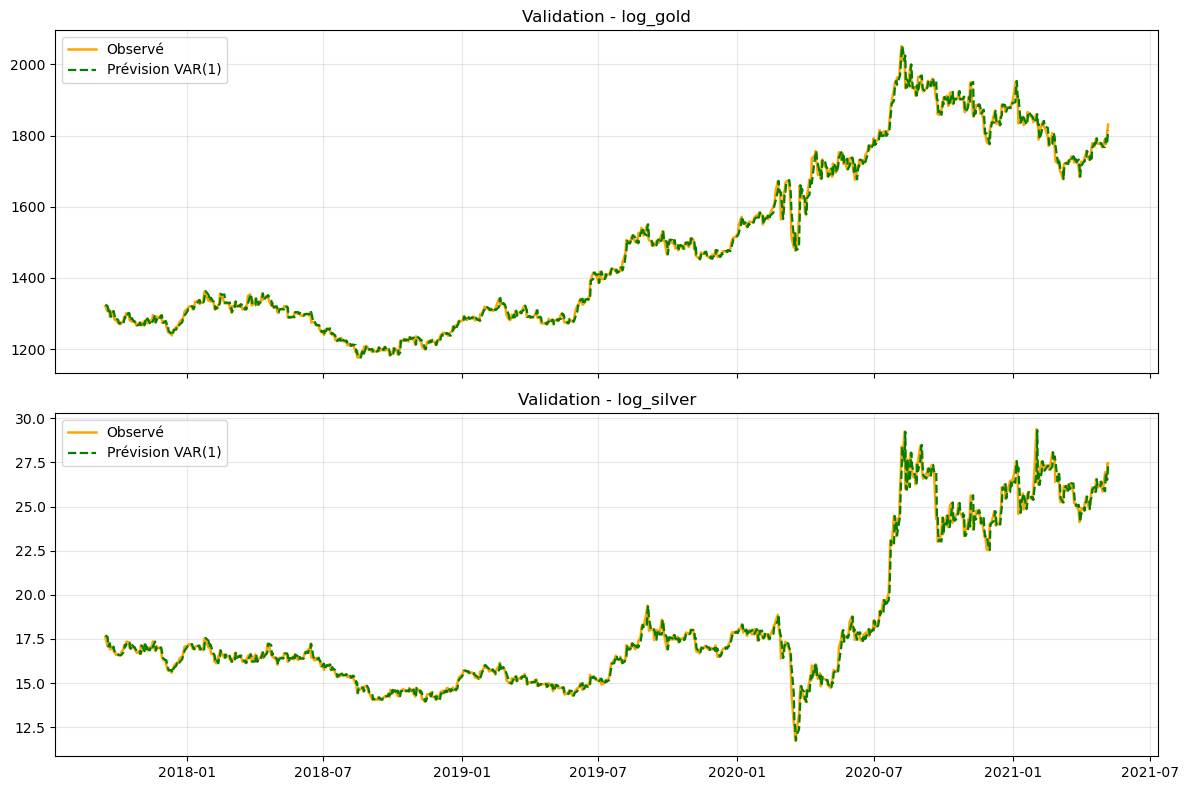

In [35]:
p_star = 1
chosen_p = p_star 

cols_to_plot = ["log_gold", "log_silver"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, col in enumerate(cols_to_plot):
    axes[i].plot(
        validation_results[chosen_p]["act_levels"].index,
        validation_results[chosen_p]["act_levels"][col],
        label="Observé",
        linewidth=1.8,
        color="orange")

    axes[i].plot(
        validation_results[chosen_p]["pred_levels"].index,
        validation_results[chosen_p]["pred_levels"][col],
        label=f"Prévision VAR({chosen_p})",
        linewidth=1.6,
        linestyle="--",
        color="green")

    axes[i].set_title(f"Validation - {col}")
    axes[i].grid(alpha = 0.3)
    axes[i].legend(loc = "upper left")

plt.tight_layout()
plt.show()

### 7.5 Évaluation sur l'échantillon de test du VAR bi-varié

In [36]:
df_all_test = pd.concat([df_train, df_val, df_test]).sort_index()

diff_df_test = (
    df_all_test[["dlog_gold", "dlog_silver"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna())

log_df_test = (
    df_all_test[["log_gold", "log_silver"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna())

test_start_idx = diff_df_test.index.searchsorted(df_test.index[0])
test_end_idx = diff_df_test.index.searchsorted(df_test.index[-1], side="right")

pred_diff_test, act_diff_test, pred_log_test, act_log_test = recursive_one_step_forecast(
    diff_df=diff_df_test,
    log_df=log_df_test,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    p=p_star)

pred_levels_test = np.exp(pred_log_test)
act_levels_test = np.exp(act_log_test)

test_metrics = level_metrics(pred_levels_test, act_levels_test)
test_metrics["Lag"] = p_star

display(test_metrics)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,RMSE,MAE,MAPE_%,Lag
Variable,,,,
log_gold,18.633947,13.676820,0.678026,1
log_silver,0.457052,0.333308,1.355087,1


Les performances hors échantillon du VAR(1) apparaissent satisfaisantes. 
Les erreurs relatives de prévision restent faibles sur l’échantillon test, avec des MAPE inférieurs à 2 % (environ 0.68% pour l'or et 1.36% pour l'argent) pour les deux actifs. 
Le modèle semble ainsi capable de reproduire correctement les dynamiques de court terme des prix de l’or et de l’argent dans un cadre de prévision récursive one-step ahead.

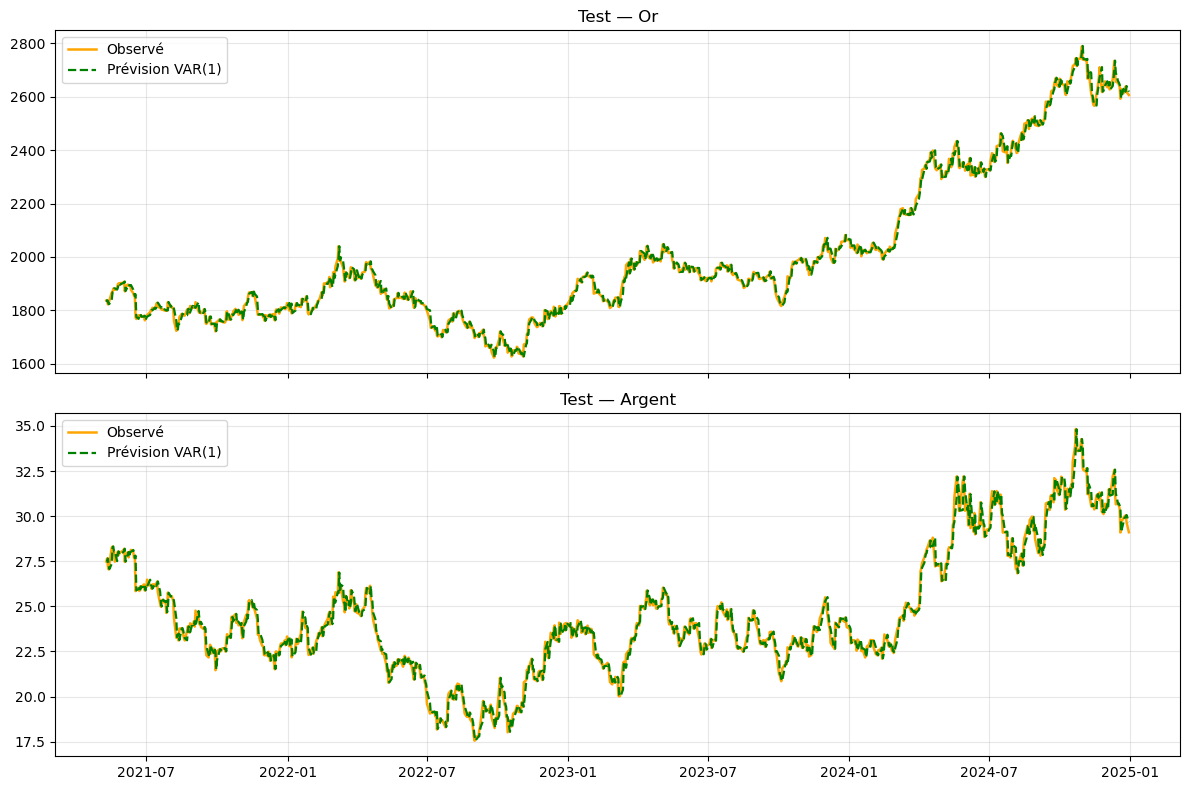

In [37]:
labels = {
    "log_gold": "Or",
    "log_silver": "Argent"}

cols_to_plot = ["log_gold", "log_silver"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, col in enumerate(cols_to_plot):
    axes[i].plot(
        act_levels_test.index,
        act_levels_test[col],
        label="Observé",
        linewidth=1.8,
        color="Orange")

    axes[i].plot(
        pred_levels_test.index,
        pred_levels_test[col],
        label=f"Prévision VAR({p_star})",
        linewidth=1.6,
        linestyle="--",
        color="green")

    axes[i].set_title(f"Test — {labels[col]}")
    axes[i].grid(alpha=0.3)
    axes[i].legend(loc="upper left")

plt.tight_layout()
plt.show()

### 7.6 Ré-estimation sur l'échantillon complet

In [38]:
df_var_final = (
    df[["dlog_gold", "dlog_silver"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna())

final_var_full = VAR(df_var_final).fit(p_star)

print(final_var_full.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     20:13:46
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -17.8245
Nobs:                     6106.00    HQIC:                  -17.8288
Log likelihood:           37116.3    FPE:                1.80319e-08
AIC:                     -17.8311    Det(Omega_mle):     1.80142e-08
--------------------------------------------------------------------
Results for equation dlog_gold
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000370         0.000139            2.656           0.008
L1.dlog_gold          -0.002539         0.020486           -0.124           0.901
L1.dlog_silver        -0.008322         0.011268    

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Les coefficients autorégressifs estimés apparaissent globalement peu significatifs ce qui est cohérent avec la faible prévisibilité des rendements journaliers financiers. 

En revanche, la matrice de corrélation des résidus met en évidence une forte corrélation contemporaine entre les innovations affectant l’or et l’argent suggérant une réaction commune aux chocs de marché et aux conditions macrofinancières.

### 7.7 Diagnostics des résidus : VAR(1)

In [39]:
white_test = final_var_full.test_whiteness(nlags=12)
normal_test = final_var_full.test_normality()

diagnostic_table = pd.DataFrame({
    "Test": [
        "Whiteness",
        "Normalité"],

    "Hypothèse nulle": [
        "Absence d'autocorrélation résiduelle",
        "Normalité multivariée des résidus"],

    "Statistique": [
        round(white_test.test_statistic, 4),
        round(normal_test.test_statistic, 4)],

    "p-value": [
        round(white_test.pvalue, 4),
        round(normal_test.pvalue, 4)],

    "Décision (5%)": [
        "Non-rejet H0"
        if white_test.pvalue > 0.05
        else "Rejet H0",
        "Non-rejet H0"
        if normal_test.pvalue > 0.05
        else "Rejet H0" ],

    "Conclusion": [
        "Absence d'autocorrélation résiduelle : résidus assimilables à un bruit blanc"
        if white_test.pvalue > 0.05
        else "Présence d'autocorrélation résiduelle",

        "Normalité des résidus"
        if normal_test.pvalue > 0.05
        else "Non-normalité des résidus"]
})

display(diagnostic_table)

,Test,Hypothèse nulle,Statistique,p-value,Décision (5%),Conclusion
0,Whiteness,Absence d'autocorrélation résiduelle,105.5684,0.0,Rejet H0,Présence d'autocorrélation résiduelle
1,Normalité,Normalité multivariée des résidus,23451.7751,0.0,Rejet H0,Non-normalité des résidus


Les tests diagnostiques mettent en évidence une autocorrélation résiduelle ainsi qu’une non-normalité des résidus. 
Ces résultats sont fréquents dans les séries financières à fréquence journalière caractérisées par des phénomènes de volatilité conditionnelle, de leptokurtose et de dépendances dynamiques complexes. 
Ils suggèrent que le VAR linéaire capture imparfaitement l’ensemble de la dynamique des rendements tout en restant pertinent pour l’analyse des interdépendances moyennes entre les deux actifs.

### 7.8 Diagnostics résiduels sous spécifications alternatives : VAR(2) et VAR(4)

Afin d’évaluer la sensibilité des diagnostics résiduels au choix du lag, une spécification alternative VAR(2) est également estimée. 
Cette analyse complémentaire permet de vérifier si l’ajout d’une dynamique supplémentaire améliore les propriétés des résidus notamment en termes d’autocorrélation et de normalité sans remettre en cause le choix du modèle principal retenu pour l’analyse.

In [40]:
var2 = VAR(df_var_final).fit(2)

white2 = var2.test_whiteness(nlags=12)
normal2 = var2.test_normality()

diagnostic_var2 = pd.DataFrame({
    "Test": [
        "Whiteness",
        "Normalité"],

    "Hypothèse nulle": [
        "Absence d'autocorrélation résiduelle",
        "Normalité multivariée des résidus"],

    "Statistique": [
        round(white2.test_statistic, 4),
        round(normal2.test_statistic, 4)],

    "p-value": [
        round(white2.pvalue, 4),
        round(normal2.pvalue, 4)],

    "Décision (5%)": [

        "Non-rejet H0"
        if white2.pvalue > 0.05
        else "Rejet H0",
        "Non-rejet H0"
        if normal2.pvalue > 0.05
        else "Rejet H0"],

    "Conclusion": [

        "Absence d'autocorrélation résiduelle : résidus assimilables à un bruit blanc"
        if white2.pvalue > 0.05
        else "Présence d'autocorrélation résiduelle",

        "Normalité acceptable"
        if normal2.pvalue > 0.05
        else "Non-normalité des résidus"]
})

display(diagnostic_var2)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Test,Hypothèse nulle,Statistique,p-value,Décision (5%),Conclusion
0,Whiteness,Absence d'autocorrélation résiduelle,92.4580,0.0,Rejet H0,Présence d'autocorrélation résiduelle
1,Normalité,Normalité multivariée des résidus,23353.8282,0.0,Rejet H0,Non-normalité des résidus


In [41]:
var4 = VAR(df_var_final).fit(4)

white4 = var4.test_whiteness(nlags=12)
normal4 = var4.test_normality()

diagnostic_var4 = pd.DataFrame({
    "Test": ["Whiteness", "Normalité"],

    "Hypothèse nulle": [
        "Absence d'autocorrélation des résidus",
        "Normalité multivariée des résidus"],

    "Statistique": [
        round(white4.test_statistic, 4),
        round(normal4.test_statistic, 4) ],

    "p-value": [
        round(white4.pvalue, 4),
        round(normal4.pvalue, 4)],

    "Décision (5%)": [
        "Non-rejet H0" if white4.pvalue > 0.05 else "Rejet H0",
        "Non-rejet H0" if normal4.pvalue > 0.05 else "Rejet H0"],

    "Conclusion": [
        "Absence d'autocorrélation résiduelle" if white4.pvalue > 0.05 else "Présence d'autocorrélation résiduelle",
        "Normalité des résidus" if normal4.pvalue > 0.05 else "Non-normalité des résidus" ]
})

display(diagnostic_var4)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Test,Hypothèse nulle,Statistique,p-value,Décision (5%),Conclusion
0,Whiteness,Absence d'autocorrélation des résidus,78.5558,0.0,Rejet H0,Présence d'autocorrélation résiduelle
1,Normalité,Normalité multivariée des résidus,23522.4044,0.0,Rejet H0,Non-normalité des résidus


Les diagnostics résiduels ont été reproduits sur des spécifications alternatives VAR(2) et VAR(4) afin d’évaluer la sensibilité des résultats au choix du lag. 
Les conclusions demeurent globalement inchangées : les tests mettent systématiquement en évidence une autocorrélation résiduelle ainsi qu’une non-normalité des résidus. 
L’ajout de dynamiques supplémentaires n’améliore donc pas significativement les propriétés statistiques du modèle. 
Ces résultats confortent le choix du VAR(1) retenu comme spécification principale pour des raisons de parcimonie.

## 8. Causalité et dynamiques du VAR(1) bivarié

### 8.1 Causalité au sens de Granger

La causalité au sens de Granger est testée afin d’évaluer si les rendements passés d’un métal apportent une information statistiquement significative pour prévoir les rendements de l’autre métal. 

In [42]:
variables = ["dlog_gold", "dlog_silver"]

granger_rows = []

for caused in variables:
    for causing in variables:
        if caused != causing:
            test = final_var_full.test_causality(
                caused,
                [causing],
                kind="f")

            granger_rows.append({
                "Variable expliquée": caused,
                "Variable causale testée": causing,
                "Hypothèse nulle":
                    f"{causing} ne cause pas {caused}",
                "Statistique F":
                    round(test.test_statistic, 4),
                "p-value":
                    round(test.pvalue, 4),
                "Décision (5%)":
                    "Rejet H0"
                    if test.pvalue < 0.05
                    else "Non-rejet H0",
                "Conclusion":
                    "Causalité au sens de Granger"
                    if test.pvalue < 0.05
                    else "Pas de causalité au sens de Granger"})

granger_table = pd.DataFrame(granger_rows)
display(granger_table)

,Variable expliquée,Variable causale testée,Hypothèse nulle,Statistique F,p-value,Décision (5%),Conclusion
0,dlog_gold,dlog_silver,dlog_silver ne cause pas dlog_gold,0.5455,0.4602,Non-rejet H0,Pas de causalité au sens de Granger
1,dlog_silver,dlog_gold,dlog_gold ne cause pas dlog_silver,0.8547,0.3552,Non-rejet H0,Pas de causalité au sens de Granger


Les tests de causalité au sens de Granger ne permettent pas de rejeter l’hypothèse nulle d’absence de causalité dans les deux directions. 
Les rendements passés de l’or ne semblent donc pas améliorer significativement la prévision des rendements de l’argent et inversement. 
Les variations passées d’un métal ne fournissent pas d’information prédictive statistiquement significative sur les variations futures de l’autre métal dans le cadre du modèle VAR estimé.

### 8.2 Causalité instantanée

In [43]:
test_inst = final_var_full.test_inst_causality(
    causing=["dlog_silver"])

instant_table = pd.DataFrame([{
    "Variables testées": "dlog_gold ↔ dlog_silver : rendements de l’or et de l’argent",
    "Hypothèse nulle": "Absence de causalité instantanée entre les deux variables",
    "Statistique": round(test_inst.test_statistic, 4),
    "p-value": round(test_inst.pvalue, 4),
    "Décision (5%)": "Rejet H0" if test_inst.pvalue < 0.05 else "Non-rejet H0",
    "Conclusion": (
        "Causalité instantanée entre les deux variables"
        if test_inst.pvalue < 0.05
        else "Pas de causalité instantanée entre les deux variables")
}])

display(instant_table)

,Variables testées,Hypothèse nulle,Statistique,p-value,Décision (5%),Conclusion
0,dlog_gold ↔ dlog_silver : rendements de l’or e...,Absence de causalité instantanée entre les deu...,2312.9264,0.0,Rejet H0,Causalité instantanée entre les deux variables


Le test de causalité instantanée (test symétrique) met en évidence une dépendance contemporaine significative entre les rendements de l’or et de l’argent. Ce résultat suggère que les deux métaux  réagissent simultanément à des chocs communs ou à des informations macrofinancières partagées. Ainsi, même en l’absence de pouvoir prédictif retardé entre les deux séries, une forte interaction contemporaine demeure présente.

### 8.3 Orthogonalisation des chocs : décomposition de Cholesky

La matrice de covariance des résidus est décomposée manuellement par la méthode de Cholesky afin d'orthogonaliser les chocs structurels. L'ordre retenu place l'or en premier, ce qui revient à supposer que l'or réagit instantanément à ses propres chocs mais pas à ceux de l'argent à la même date.

In [44]:
Sigma_u = final_var_full.sigma_u.to_numpy()

print("Matrice de covariance des résidus Σu :")
display(final_var_full.sigma_u)

s11 = Sigma_u[0, 0]
s12 = Sigma_u[0, 1]
s22 = Sigma_u[1, 1]

p11 = np.sqrt(s11)
p21 = s12 / p11
p22 = np.sqrt(s22 - p21**2)

P = np.array([
    [p11, 0.0],
    [p21, p22]])

P_table = pd.DataFrame(P,index=final_var_full.sigma_u.index, columns=final_var_full.sigma_u.columns)

print("\nMatrice de Cholesky P (matrice triangulaire inférieure):")
display(P_table)

Sigma_reconstructed = P @ P.T

verification_table = pd.DataFrame(
    Sigma_reconstructed,
    index=final_var_full.sigma_u.index,
    columns=final_var_full.sigma_u.columns)

print("\nVérification : P × P' :")
display(verification_table)

ecart_table = pd.DataFrame(
    Sigma_u - Sigma_reconstructed,
    index=final_var_full.sigma_u.index,
    columns=final_var_full.sigma_u.columns)

print("\nÉcart numérique Σu - P × P' :")
display(ecart_table)

Matrice de covariance des résidus Σu :


,dlog_gold,dlog_silver
dlog_gold,0.000118,0.000168
dlog_silver,0.000168,0.000391



Matrice de Cholesky P (matrice triangulaire inférieure):


,dlog_gold,dlog_silver
dlog_gold,0.010872,0.000000
dlog_silver,0.015433,0.012346



Vérification : P × P' :


,dlog_gold,dlog_silver
dlog_gold,0.000118,0.000168
dlog_silver,0.000168,0.000391



Écart numérique Σu - P × P' :


,dlog_gold,dlog_silver
dlog_gold,-1.355253e-20,0.0
dlog_silver,0.000000e+00,0.0


La matrice de covariance des résidus met en évidence une covariance positive importante entre les innovations de l’or et de l’argent confirmant l’existence d’une forte dépendance contemporaine entre les deux métaux. 
La décomposition de Cholesky permet ensuite d’orthogonaliser ces chocs en imposant une structure récursive où l’or est placé en premier. La structure triangulaire de la matrice obtenue reflète cette hypothèse d’identification contemporaine.

In [45]:
ut = final_var_full.resid[
    ["dlog_gold", "dlog_silver"]].to_numpy()

# Inverse de la matrice de Cholesky
P_inv = np.linalg.inv(P)

# Chocs orthogonaux 
vt = (P_inv @ ut.T).T
vt = pd.DataFrame(
    vt,
    index=final_var_full.resid.index,
    columns=["v1", "v2"])


# Matrice variance-covariance des chocs orthogonaux
Sigma_v = np.cov(vt.T, bias=False)
Sigma_v_df = pd.DataFrame(
    Sigma_v,
    index=["v1", "v2"],
    columns=["v1", "v2"])

print("Matrice variance-covariance des chocs orthogonaux :")
display(Sigma_v_df)

# Corrélation des chocs orthogonaux
print("\nMatrice de corrélation des chocs orthogonaux :")
display(vt.corr())

Matrice variance-covariance des chocs orthogonaux :


,v1,v2
v1,9.996724e-01,-2.898037e-16
v2,-2.898037e-16,9.996724e-01



Matrice de corrélation des chocs orthogonaux :


,v1,v2
v1,1.000000e+00,-2.311949e-16
v2,-2.311949e-16,1.000000e+00


La matrice variance-covariance des chocs orthogonalisés est proche de la matrice identité : les variances sont égales à 1 et les covariances hors diagonale sont numériquement nulles. 
La matrice de corrélation confirme également l’absence de corrélation entre les chocs orthogonaux. 
La décomposition de Cholesky a donc bien permis de transformer les résidus corrélés du VAR en chocs structurels orthogonaux.

### 8.4 Fonctions de réponse impulsionnelle (IRF) 

Les fonctions de réponse impulsionnelle sont calculées manuellement à partir de la représentation moyenne mobile (MA) du VAR(1). 
Les matrices Φh décrivent la propagation dynamique des chocs dans le système, tandis que la matrice de Cholesky permet d’orthogonaliser les innovations contemporanément corrélées. 
L’horizon retenu est de 20 jours ouvrés, correspondant approximativement à un mois de cotation.

In [46]:
k = final_var_full.neqs  
p = final_var_full.k_ar # nombre de retards du VAR
A = final_var_full.coefs # matrices de coefficients du VAR
H = 20 # horizon de 20 jours ouvrés équivalent à 1 mois de trading

Phi = np.zeros((H + 1, k, k))
Phi[0] = np.eye(k) 

for h in range(1, H + 1):
    temp = np.zeros((k, k))
    for j in range(1, min(p, h) + 1):
        temp += A[j - 1] @ Phi[h - j]
    Phi[h] = temp

IRF_manuelle = np.zeros((H + 1, k, k))
for h in range(H + 1):
    IRF_manuelle[h] = Phi[h] @ P

Pour chaque choc structurel orthogonal, les fonctions de réponse impulsionnelle retracent l’évolution dynamique des rendements de l’or et de l’argent sur un horizon de 20 jours ouvrés. 
Chaque courbe mesure l’impact d’un choc unitaire sur la trajectoire future des variables du système.

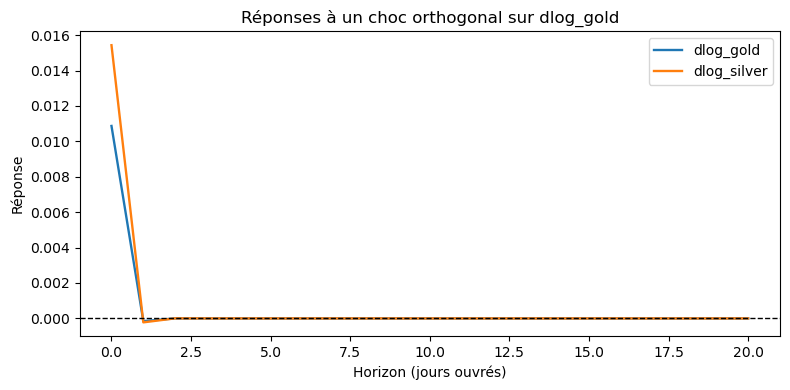

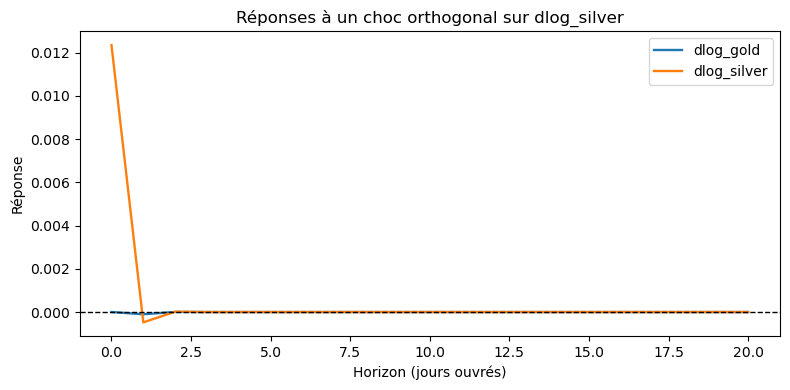

In [47]:
noms = final_var_full.names

for j, choc in enumerate(noms):
    plt.figure(figsize=(8, 4))
    for i, var in enumerate(noms):
        plt.plot(
            range(H + 1),
            IRF_manuelle[:, i, j],
            label=var,
            linewidth=1.7)

    plt.axhline(
        0,
        color="black",
        linewidth=1,
        linestyle="--")

    plt.title(f"Réponses à un choc orthogonal sur {choc}")
    plt.xlabel("Horizon (jours ouvrés)")
    plt.ylabel("Réponse")
    plt.legend()
    plt.tight_layout()
    plt.show()

Les fonctions de réponse impulsionnelle montrent que les chocs affectant les rendements de l’or et de l’argent produisent principalement des effets contemporains de courte durée. 

Les réponses convergent rapidement vers zéro après un à deux jours ouvrés suggérant une faible persistance dynamique des chocs dans le système. 

Les réactions contemporaines positives observées entre les deux métaux confirment néanmoins l’existence d’une forte interdépendance instantanée entre les marchés de l’or et de l’argent.

### 8.5 Décomposition de la variance de l'erreur de prévision (FEVD) 

La décomposition de la variance de l’erreur de prévision est calculée à partir des fonctions de réponse impulsionnelle orthogonalisées. Elle permet de mesurer, pour chaque horizon, la part de la variance de l’erreur de prévision d’une variable attribuable aux différents chocs structurels du système.

In [48]:
FEVD = np.zeros((H, k, k))

for h in range(1, H + 1):
    for i in range(k):
        denom = sum(np.sum(IRF_manuelle[:h, i, m] ** 2) for m in range(k))
        for j in range(k):
            num = np.sum(IRF_manuelle[:h, i, j] ** 2)
            FEVD[h - 1, i, j] = num / denom if denom != 0 else np.nan

In [49]:
for i, var in enumerate(noms):
    table_fevd = pd.DataFrame(
        np.round(FEVD[:, i, :] * 100, 2),
        index=range(1, H + 1),
        columns=[f"Choc {name}" for name in noms])

    print(f"\nFEVD de {var} (en %)")
    display(table_fevd)


FEVD de dlog_gold (en %)


,Choc dlog_gold,Choc dlog_silver
1,100.00,0.00
2,99.99,0.01
3,99.99,0.01
4,99.99,0.01
5,99.99,0.01
6,99.99,0.01
7,99.99,0.01
8,99.99,0.01
9,99.99,0.01
10,99.99,0.01



FEVD de dlog_silver (en %)


,Choc dlog_gold,Choc dlog_silver
1,60.98,39.02
2,60.95,39.05
3,60.95,39.05
4,60.95,39.05
5,60.95,39.05
6,60.95,39.05
7,60.95,39.05
8,60.95,39.05
9,60.95,39.05
10,60.95,39.05


La FEVD montre que la variance de l’erreur de prévision des rendements de l’or est presque exclusivement expliquée par ses propres chocs structurels, quelle que soit l’horizon considéré. 

À l’inverse, une part importante de la variance des rendements de l’argent est attribuable aux chocs sur l’or traduisant une influence contemporaine plus forte de l’or sur l’argent au sein du système étudié. 

La convergence rapide des proportions confirme également la faible persistance dynamique mise en évidence par les fonctions de réponse impulsionnelle

## 9. VECM bivarié sur l'épisode principal de cointégration

### 9.1 Identification de l'épisode de cointégration

Le plus long épisode détecté par le rolling Engle-Granger est isolé et utilisé comme fenêtre d'estimation du VECM.

In [50]:
# repérage des épisodes de cointégration à partir du rolling EG
threshold = 0.05

rolling_eg = rolling_eg.copy()
rolling_eg["cointegrated"] = rolling_eg["p-value"] < threshold

intervals = []
start = None

for date, row in rolling_eg.iterrows():
    if row["cointegrated"] and start is None:
        start = date
    elif (not row["cointegrated"]) and (start is not None):
        end = date
        intervals.append((start, end))
        start = None

if start is not None:
    intervals.append((start, rolling_eg.index[-1]))

intervals_df = pd.DataFrame(intervals, columns=["Start", "End"])
intervals_df["Duration_days"] = (intervals_df["End"] - intervals_df["Start"]).dt.days

intervals_df = intervals_df.sort_values("Duration_days", ascending=False).reset_index(drop=True)

intervals_df

,Start,End,Duration_days
0,2015-05-05,2016-02-12,283
1,2006-08-10,2006-10-03,54
2,2006-10-12,2006-11-22,41
3,2017-01-31,2017-03-06,34
4,2015-03-18,2015-04-17,30
5,2017-03-09,2017-04-03,25
6,2007-02-01,2007-02-16,15
7,2007-11-12,2007-11-26,14
8,2007-01-02,2007-01-11,9
9,2007-03-05,2007-03-14,9


In [51]:
interval_obs = []

for start, end in intervals:
    n_obs = rolling_eg.loc[start:end].shape[0]
    
    interval_obs.append({
        "Start": start,
        "End": end,
        "Duration_days": (end - start).days,
        "N_observations": n_obs })

interval_obs_df = pd.DataFrame(interval_obs)
interval_obs_df.sort_values(
    by="N_observations",
    ascending=False)

,Start,End,Duration_days,N_observations
31,2015-05-05,2016-02-12,283,197
6,2006-08-10,2006-10-03,54,39
7,2006-10-12,2006-11-22,41,30
35,2017-01-31,2017-03-06,34,24
27,2015-03-18,2015-04-17,30,22
36,2017-03-09,2017-04-03,25,18
14,2007-02-01,2007-02-16,15,12
23,2007-11-12,2007-11-26,14,10
16,2007-03-05,2007-03-14,9,8
10,2007-01-02,2007-01-11,9,8


In [52]:
best_interval = intervals_df.sort_values("Duration_days", ascending=False).iloc[0]
start = pd.Timestamp("2015-05-05")
end   = pd.Timestamp("2016-02-12")

vecm_data = df.loc[start:end, ["log_gold", "log_silver"]].dropna().copy()

### 9.2 Sélection du lag et test de Johansen local

In [53]:
from statsmodels.tsa.vector_ar.vecm import select_order
lag_order = select_order(vecm_data, maxlags=10, deterministic="co")
lag_order.summary()

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,AIC,BIC,FPE,HQIC
0,-18.33*,-18.19*,1.096e-08*,-18.27*
1,-18.30,-18.09,1.133e-08,-18.21
2,-18.31,-18.03,1.121e-08,-18.19
3,-18.32,-17.98,1.103e-08,-18.18
4,-18.29,-17.87,1.141e-08,-18.12
5,-18.27,-17.79,1.162e-08,-18.07
6,-18.29,-17.73,1.146e-08,-18.06
7,-18.25,-17.62,1.191e-08,-17.99
8,-18.25,-17.56,1.188e-08,-17.97
9,-18.23,-17.46,1.218e-08,-17.92


In [54]:
johansen_test = coint_johansen(vecm_data, det_order=0, k_ar_diff=0)
print("Trace stats :", johansen_test.lr1)
print("Critical values (5%) :", johansen_test.cvt[:,1])

Trace stats : [20.67615012  2.59524997]
Critical values (5%) : [15.4943  3.8415]


### 9.3 Stationnarité sur sous-période

In [55]:
vecm_data = df.loc[start:end, ["log_gold", "log_silver", "log_ratio"]].dropna().copy()
vecm_diff = vecm_data.diff().dropna().copy()

level_table_vecm = stationarity_table(vecm_data)
diff_table_vecm  = stationarity_table(vecm_diff)

print("Niveaux")
display(level_table_vecm)
print("Différences premières")
display(diff_table_vecm)

Niveaux


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,0.164163,0.736158,Non stationnaire,0.846121,0.01,Non stationnaire
log_silver,-0.260073,0.591369,Non stationnaire,1.140613,0.01,Non stationnaire
log_ratio,0.590823,0.844910,Non stationnaire,1.067374,0.01,Non stationnaire


Différences premières


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,-2.927806,3.353212e-03,Stationnaire,0.386726,0.082877,Stationnaire
log_silver,-14.981472,1.253880e-26,Stationnaire,0.156204,0.100000,Stationnaire
log_ratio,-15.250943,5.986871e-27,Stationnaire,0.030810,0.100000,Stationnaire


### 9.4 Estimation du VECM bivarié

In [56]:
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, coint_johansen

best_interval = intervals_df.iloc[0]
start = best_interval["Start"]
end   = best_interval["End"]

vecm_data = (
    df.loc[start:end, ["log_gold", "log_silver"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy())

print("Période VECM :", start.date(), "→", end.date())
print("Nombre d'observations :", len(vecm_data))

lag_order = select_order(vecm_data, maxlags=10, deterministic="co")
display(lag_order.summary())

k_ar_diff = lag_order.aic
print("k_ar_diff retenu :", k_ar_diff)

johansen_test = coint_johansen(vecm_data, det_order=0, k_ar_diff=k_ar_diff)

print("Trace stats :", johansen_test.lr1)
print("Critical values 5% :", johansen_test.cvt[:, 1])

vecm_model = VECM(vecm_data, k_ar_diff=k_ar_diff, coint_rank=1, deterministic="co")
vecm_res = vecm_model.fit()
vecm_res.summary()

Période VECM : 2015-05-05 → 2016-02-12
Nombre d'observations : 197


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,AIC,BIC,FPE,HQIC
0,-18.33*,-18.19*,1.096e-08*,-18.27*
1,-18.30,-18.09,1.133e-08,-18.21
2,-18.31,-18.03,1.121e-08,-18.19
3,-18.32,-17.98,1.103e-08,-18.18
4,-18.29,-17.87,1.141e-08,-18.12
5,-18.27,-17.79,1.162e-08,-18.07
6,-18.29,-17.73,1.146e-08,-18.06
7,-18.25,-17.62,1.191e-08,-17.99
8,-18.25,-17.56,1.188e-08,-17.97
9,-18.23,-17.46,1.218e-08,-17.92


k_ar_diff retenu : 0
Trace stats : [20.67615012  2.59524997]
Critical values 5% : [15.4943  3.8415]


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.1934,0.131,-1.478,0.139,-0.450,0.063
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.5832,0.213,-2.739,0.006,-1.000,-0.166
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.0420,0.028,1.480,0.139,-0.014,0.098
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.1265,0.046,2.738,0.006,0.036,0.217
,coef,std err,z,P>|z|,[0.025,0.975]
beta.1,1.0000,0,0,0.000,1.000,1.000
beta.2,-0.8929,0.140,-6.359,0.000,-1.168,-0.618


In [57]:
def recursive_one_step_forecast_vecm(vecm_data_full, log_cols, start_idx, end_idx, k_ar_diff, coint_rank, deterministic="co"):
    
    pred_log, act_log = [], []
    idx = []

    for t in range(start_idx, end_idx):
        history = vecm_data_full[log_cols].iloc[:t]

        model = VECM(history, k_ar_diff=k_ar_diff, coint_rank=coint_rank, deterministic=deterministic)
        res = model.fit()

        fc = res.predict(steps=1)  
        pred_log.append(fc[0])
        act_log.append(vecm_data_full[log_cols].iloc[t].values)
        idx.append(vecm_data_full.index[t])

    pred_log = pd.DataFrame(pred_log, index=idx, columns=log_cols)
    act_log  = pd.DataFrame(act_log,  index=idx, columns=log_cols)

    return pred_log, act_log

### 9.5 Discussion méthodologique

Au départ, l'idée était d'utiliser un VECM afin de modéliser la relation de long terme entre les prix de l'or et de l'argent. Cependant, plusieurs difficultés méthodologiques sont apparues au cours de l'analyse.

Les tests de cointégration globaux (Engle-Granger et Johansen) ne montrent pas de relation de cointégration stable sur l'ensemble de l'échantillon. En revanche, l'approche rolling met en évidence des épisodes ponctuels de cointégration, notamment entre 2015 et 2016.

Le principal problème est alors devenu le suivant : est-il économétriquement cohérent d'estimer un VECM sur une période relativement courte ( 197 observations) détectée précisément parce qu'elle présente de la cointégration ?

D'un point de vue rigoureux, cette approche possède plusieurs limites :

- la taille d'échantillon reste faible pour un système dynamique multivarié ;
- la fenêtre est sélectionnée de manière endogène après détection de la cointégration ;
- les résultats peuvent être sensibles au choix exact des dates et du nombre de retards ;
- cela empêche de conclure à une relation structurelle stable sur l'ensemble de la période étudiée.

Pour ces raisons, le VECM ne peut pas être considéré ici comme le modèle central du projet.

Néanmoins, plusieurs éléments rendent les résultats suffisamment cohérents et intéressants pour conserver cette analyse comme exploration locale d'un épisode spécifique.

Les fonctions de réponse impulsionnelle (IRF) obtenues sont économiquement cohérentes : les réponses sont lisses et convergentes, les dynamiques ne présentent pas d'explosion ou d'instabilité numérique, un choc sur l'or entraîne une réaction positive de l'argent.

Le vecteur de cointégration estimé :

$$\log(gold_t) - 0.8929 \log(silver_t) = 0$$

est économiquement plausible (coefficient positif, proche de 1, statistiquement significatif). L'analyse des coefficients d'ajustement révèle que l'or n'est pas significatif (price leader) tandis que l'argent ajuste (price follower), ce qui est cohérent avec la réalité des marchés.

Le VECM est conservé non pas comme preuve définitive d'une relation structurelle stable mais comme outil exploratoire permettant d'étudier localement les mécanismes de transmission observés durant cet épisode.

### 9.6 Relation de long terme : vecteur bêta

In [58]:
beta_table = pd.DataFrame({
    "Variable"   : vecm_data.columns,
    "Beta"       : vecm_res.beta[:, 0],
    "Std_Error"  : vecm_res.stderr_beta[:, 0],
    "t_stat"     : vecm_res.tvalues_beta[:, 0],
    "p_value"    : vecm_res.pvalues_beta[:, 0]})

beta_table

,Variable,Beta,Std_Error,t_stat,p_value
0,log_gold,1.000000,0.000000,0.000000,0.000000e+00
1,log_silver,-0.892944,0.140416,-6.359255,2.027352e-10


### 9.7 Coefficients d'ajustement : vecteur alpha

In [59]:
alpha_table = pd.DataFrame({
    "Equation"   : ["dlog_gold", "dlog_silver"],
    "Alpha"      : vecm_res.alpha[:, 0],
    "Std_Error"  : vecm_res.stderr_alpha[:, 0],
    "t_stat"     : vecm_res.tvalues_alpha[:, 0],
    "p_value"    : vecm_res.pvalues_alpha[:, 0]})

alpha_table

,Equation,Alpha,Std_Error,t_stat,p_value
0,dlog_gold,0.042014,0.028390,1.479894,0.138901
1,dlog_silver,0.126475,0.046198,2.737679,0.006187


### 9.8 Relation normalisée et terme de correction d'erreur (ECT)

In [60]:
b_gold   = vecm_res.beta[0, 0]
b_silver = vecm_res.beta[1, 0]

print("Vecteur beta estimé :")
print(f"{b_gold:.4f} * log_gold + ({b_silver:.4f}) * log_silver = 0")

beta_norm = vecm_res.beta[:, 0] / vecm_res.beta[0, 0]

print("Relation de long terme normalisée sur log_gold :")
print(f"log_gold + ({beta_norm[1]:.4f}) * log_silver = 0")
print(f"log_gold = ({-beta_norm[1]:.4f}) * log_silver")

Vecteur beta estimé :
1.0000 * log_gold + (-0.8929) * log_silver = 0
Relation de long terme normalisée sur log_gold :
log_gold + (-0.8929) * log_silver = 0
log_gold = (0.8929) * log_silver


In [61]:
beta_norm = vecm_res.beta[:, 0] / vecm_res.beta[0, 0]

vecm_data["ECT"] = (
    beta_norm[0] * vecm_data["log_gold"] +
    beta_norm[1] * vecm_data["log_silver"])

vecm_data[["log_gold", "log_silver", "ECT"]].tail()

,log_gold,log_silver,ECT
Date,,,
2016-02-08,7.088325,2.735406,4.645761
2016-02-09,7.088993,2.737221,4.644808
2016-02-10,7.085650,2.726348,4.651174
2016-02-11,7.129217,2.759313,4.665305
2016-02-12,7.122141,2.759060,4.658454


### 9.9 Tableau récapitulatif : VECM bivarié

In [62]:
beta_table["Bloc"] = "Long terme (beta)"
alpha_table["Bloc"] = "Ajustement (alpha)"

beta_table_final = beta_table.rename(columns={"Variable": "Nom", "Beta": "Coefficient"})
alpha_table_final = alpha_table.rename(columns={"Equation": "Nom", "Alpha": "Coefficient"})

vecm_summary_table = pd.concat([
    beta_table_final[["Bloc", "Nom", "Coefficient", "Std_Error", "t_stat", "p_value"]],
    alpha_table_final[["Bloc", "Nom", "Coefficient", "Std_Error", "t_stat", "p_value"]]
], axis=0).reset_index(drop=True)

vecm_summary_table

,Bloc,Nom,Coefficient,Std_Error,t_stat,p_value
0,Long terme (beta),log_gold,1.000000,0.000000,0.000000,0.000000e+00
1,Long terme (beta),log_silver,-0.892944,0.140416,-6.359255,2.027352e-10
2,Ajustement (alpha),dlog_gold,0.042014,0.028390,1.479894,1.389015e-01
3,Ajustement (alpha),dlog_silver,0.126475,0.046198,2.737679,6.187446e-03


### 9.10 IRF :  VECM bivarié

In [63]:
def plot_irf_vecm(IRF, vecm_res, H):
    noms = vecm_res.names if hasattr(vecm_res, "names") else vecm_data.columns.tolist()

    for j, choc in enumerate(noms):
        plt.figure(figsize=(8, 4))
        for i, var in enumerate(noms):
            y = IRF[:H + 1, i, j]
            x = range(H + 1)
            plt.plot(x, y, label=var, linewidth=2)
        
        y_all = IRF[:H + 1, :, j]
        plt.ylim(y_all.min() * 0.999, y_all.max() * 1.001)
        
        plt.axhline(0, color="black", linestyle="--")
        plt.title(f"Réponses à un choc sur {choc} (VECM)")
        plt.xlabel("Horizon (jours)")
        plt.ylabel("Réponse")
        plt.legend()
        plt.grid(alpha=0.2)
        
        plt.tight_layout()
        plt.show()

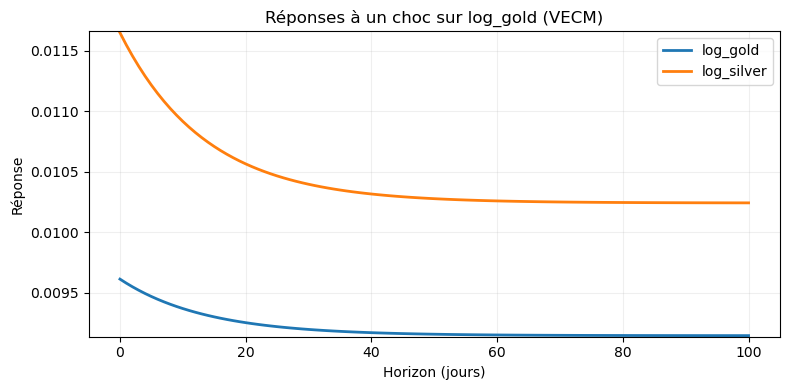

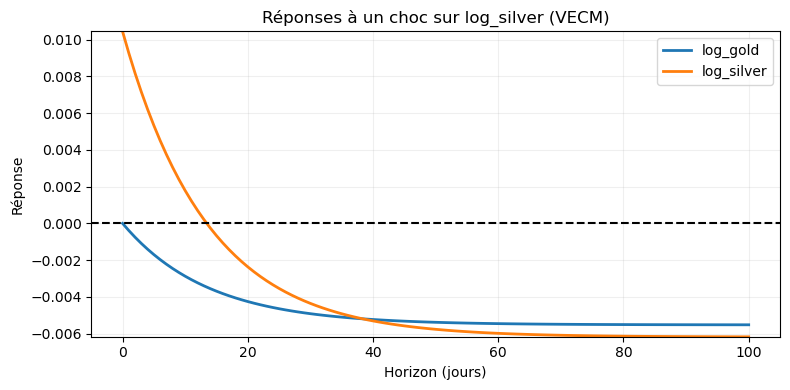

In [64]:
H=100
irf_vecm = vecm_res.irf(H)

IRF_vecm = irf_vecm.orth_irfs
plot_irf_vecm(IRF_vecm, vecm_res, H=100)

### 9.11 Validation hors échantillon : VECM bivarié

Le VECM est ré-estimé à chaque pas en utilisant uniquement l'historique disponible jusqu'à t−1.Les niveaux reconstitués sont comparés aux réalisations.

In [65]:
log_cols_bi = ["log_gold", "log_silver"]

vecm_data_bi_full = (
    df[log_cols_bi]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy())

val_start_bi = vecm_data_bi_full.index.searchsorted(df_val.index[0])
val_end_bi = vecm_data_bi_full.index.searchsorted(df_val.index[-1], side="right")

k_ar_diff_bi = k_ar_diff   

pred_log_val_bi, act_log_val_bi = recursive_one_step_forecast_vecm(
    vecm_data_full = vecm_data_bi_full,
    log_cols       = log_cols_bi,
    start_idx      = val_start_bi,
    end_idx        = val_end_bi,
    k_ar_diff      = k_ar_diff_bi,
    coint_rank     = 1,
    deterministic  = "co"
)

pred_levels_val_bi = np.exp(pred_log_val_bi)
act_levels_val_bi = np.exp(act_log_val_bi)

metrics_val_bi = level_metrics(pred_levels_val_bi, act_levels_val_bi)
print("Métriques validation : VECM bivarié")
display(metrics_val_bi)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

Métriques validation : VECM bivarié


,RMSE,MAE,MAPE_%
Variable,,,
log_gold,15.528625,10.095198,0.650328
log_silver,0.418635,0.244097,1.258861


In [ ]:
labels_bi = {"log_gold": "Or", "log_silver": "Argent"}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, col in enumerate(log_cols_bi):
    axes[i].plot(act_levels_val_bi.index, act_levels_val_bi[col], label="Réalisé", linewidth=1.8, color="black")
    axes[i].plot(pred_levels_val_bi.index, pred_levels_val_bi[col], label="Prévision VECM", linewidth=1.6, linestyle="--", color="steelblue")
    axes[i].set_title(f"Validation — {labels_bi[col]}")
    axes[i].legend(loc="upper left")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.12 Évaluation sur l'échantillon de test : VECM bivarié

In [66]:
test_start_bi = vecm_data_bi_full.index.searchsorted(df_test.index[0])
test_end_bi   = vecm_data_bi_full.index.searchsorted(df_test.index[-1], side="right")

pred_log_test_bi, act_log_test_bi = recursive_one_step_forecast_vecm(
    vecm_data_full = vecm_data_bi_full,
    log_cols       = log_cols_bi,
    start_idx      = test_start_bi,
    end_idx        = test_end_bi,
    k_ar_diff      = k_ar_diff_bi,
    coint_rank     = 1,
    deterministic  = "co")

pred_levels_test_bi = np.exp(pred_log_test_bi)
act_levels_test_bi  = np.exp(act_log_test_bi)

metrics_test_bi = level_metrics(pred_levels_test_bi, act_levels_test_bi)
print("Métriques test — VECM bivarié")
display(metrics_test_bi)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

Métriques test — VECM bivarié


,RMSE,MAE,MAPE_%
Variable,,,
log_gold,18.633948,13.665828,0.677606
log_silver,0.456870,0.333068,1.354275


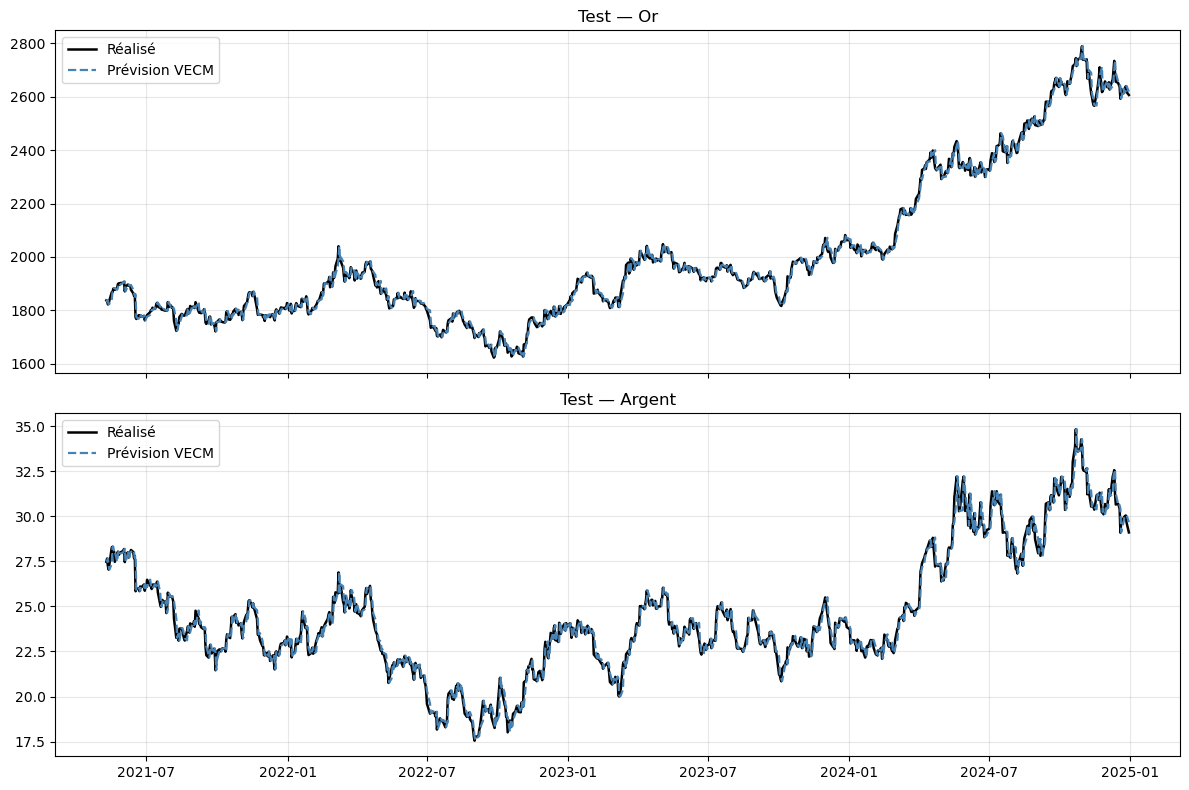

In [67]:
labels_bi = {
    "log_gold": "Or",
    "log_silver": "Argent"}
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for i, col in enumerate(log_cols_bi):
    axes[i].plot(act_levels_test_bi.index, act_levels_test_bi[col], label="Réalisé", linewidth=1.8, color="black")
    axes[i].plot(pred_levels_test_bi.index, pred_levels_test_bi[col], label="Prévision VECM", linewidth=1.6, linestyle="--", color="steelblue")
    axes[i].set_title(f"Test — {labels_bi[col]}")
    axes[i].legend(loc="upper left")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.13 Ré-estimation sur l'échantillon complet du VECM bivarié

Le VECM est ré-estimé sur tout l'échantillon avec le `k_ar_diff` retenu.

In [68]:
vecm_full_bi = VECM(vecm_data_bi_full[log_cols_bi], k_ar_diff = k_ar_diff_bi, coint_rank = 1,deterministic = "co").fit()
print(vecm_full_bi.summary())

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation log_gold
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0038      0.002     -1.649      0.099      -0.008       0.001
Det. terms outside the coint. relation & lagged endog. parameters for equation log_silver
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0115      0.004     -2.750      0.006      -0.020      -0.003
              Loading coefficients (alpha) for equation log_gold              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ec1            0.0011      0.001      1.812      0.070   -9.19e-05       0.002
             Loading coefficient

In [69]:
resid_bi = pd.DataFrame(vecm_full_bi.resid, columns=log_cols_bi)

white_bi  = sm.stats.acorr_ljungbox(resid_bi["log_gold"], lags=[12], return_df=True)
white_bi2 = sm.stats.acorr_ljungbox(resid_bi["log_silver"], lags=[12], return_df=True)

diag_bi = pd.DataFrame({
    "Série"   : ["log_gold (résidus)", "log_silver (résidus)"],
    "LB stat" : [white_bi["lb_stat"].values[0], white_bi2["lb_stat"].values[0]],
    "p-value" : [white_bi["lb_pvalue"].values[0], white_bi2["lb_pvalue"].values[0]],
    "Décision": [
        "Rejet H0" if white_bi["lb_pvalue"].values[0] < 0.05 else "Non-rejet H0",
        "Rejet H0" if white_bi2["lb_pvalue"].values[0] < 0.05 else "Non-rejet H0"
    ]})

display(diag_bi)

,Série,LB stat,p-value,Décision
0,log_gold (résidus),30.262529,0.002549,Rejet H0
1,log_silver (résidus),23.584486,0.023154,Rejet H0


# Partie II. Modèle macro-financier multivarié : cointégration et VECM


## 1. Introduction du modèle macro-financier multivarié

### 1.1 Motivation économique

Le cadre bivarié or–argent souffre d'une limite non négligeable : il ignore les facteurs macrofinanciers communs aux deux métaux. L'instabilité de la cointégration bivariée peut s'expliquer en partie par l'omission de variables de prix et de coût d'opportunité.

- **Limites du modèle bivarié** : la relation or–argent n'est pas stable sur l'ensemble de la période 2000-2024 :  les tests ne rejettent pas H0 d'absence de cointégration.
- **Rôle du dollar (DXY)** : or et argent étant cotés en dollars, une appréciation du DXY renchérit ces métaux pour les acheteurs "non-américains" et exerce une pression baissière sur les prix. Le dollar est, par conséquent un facteur de pricing commun.
- **Rôle des taux d'intérêt (US10Y)** : les métaux précieux ne versent aucun coupon. Un taux réel élevé accroît le coût d'opportunité de les détenir ce qui pèse sur les prix.
- **Transmission macro-financière** : l'hypothèse centrale est que la cointégration or-argent est conditionnelle à l'environnement monétaire global, elle devient plus stable une fois le dollar et les taux contrôlés.

### 1.2 Variables retenues dans cette analyse

| Variable | Description |
|---|---|
| `log_gold` | Log du prix de l'or (GC=F) |
| `log_silver` | Log du prix de l'argent (SI=F) |
| `log_dxy` | Log du dollar index (DX-Y.NYB) |
| `us10y` | Taux américain à 10 ans (^TNX, en niveau) |

### 1.3 Intuition économique

- **Relation inverse dollar / or** : une appréciation du dollar comprime mécaniquement les prix des métaux exprimés en USD.
- **Coût d'opportunité via les taux** : la hausse des taux réels rend les actifs (sans rendement) moins attractifs.
- **Interdépendance or / argent** : les deux métaux partagent une demande industrielle et d'investissement commune, par conséquent leurs prix réagissent aux mêmes chocs macroéconomiques.

## 2. Construction et préparation des données

### 2.1 Téléchargement et alignement des séries

In [70]:
goldd   = yf.download("GC=F", start="2000-01-01", end="2024-12-30")["Close"]
silverr = yf.download("SI=F", start="2000-01-01", end="2024-12-30")["Close"]
dxy = yf.download("DX-Y.NYB", start="2000-01-01", end="2024-12-30")["Close"]
tnx = yf.download("^TNX", start="2000-01-01", end="2024-12-30")["Close"]

df_macro = pd.concat([gold, silver, dxy, tnx], axis=1)
df_macro.columns = [ "gold", "silver","dxy","us10y"]
df_macro

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,gold,silver,dxy,us10y
Date,,,,
2000-01-03,NaN,NaN,100.220001,6.548
2000-01-04,NaN,NaN,100.410004,6.485
2000-01-05,NaN,NaN,100.379997,6.599
2000-01-06,NaN,NaN,100.650002,6.549
2000-01-07,NaN,NaN,100.800003,6.504
...,...,...,...,...
2024-12-23,2612.300049,29.888000,108.040001,4.599
2024-12-24,2620.000000,29.974001,108.260002,4.591
2024-12-26,2638.800049,30.047001,108.129997,4.579


In [71]:
print("Nombre d'observations initiales :", len(df_macro))
print("\nValeurs manquantes avant imputation :")
print(df_macro.isna().sum())
print("\nPourcentage de NaN :")
print((df_macro.isna().sum() / len(df_macro) * 100).round(3), "%")

Nombre d'observations initiales : 6319

Valeurs manquantes avant imputation :
gold      214
silver    212
dxy         5
us10y      38
dtype: int64

Pourcentage de NaN :
gold      3.387
silver    3.355
dxy       0.079
us10y     0.601
dtype: float64 %


### 2.2 Gestion des fréquences et des dates
Les quatre séries sont téléchargées en fréquence journalière sur 2000-2024. Les données de marché produisent des NaN les jours fériés : un forward fill est appliqué (même logique que pour le modèle bivarié). Les observations résiduellement manquantes en début de série sont supprimées via `dropna()`.

In [72]:
df_macro = df_macro.sort_index()
print("Nombre d'observations initiales :", len(df_macro))

df_macro["log_gold"] = np.log(df_macro["gold"])
df_macro["log_silver"] = np.log(df_macro["silver"])
df_macro["log_dxy"] = np.log(df_macro["dxy"])

df_macro_ffill = df_macro.ffill()
df_macro_ffill = df_macro_ffill.dropna()
df_macro = df_macro_ffill.copy()

print("\nNombre d'observations final :", len(df_macro))
print("\nValeurs manquantes restantes :")
print(df_macro.isna().sum())

df_macro["dlog_gold"] = df_macro["log_gold"].diff()
df_macro["dlog_silver"] = df_macro["log_silver"].diff()
df_macro["dlog_dxy"] = df_macro["log_dxy"].diff()
df_macro["dus10y"] = df_macro["us10y"].diff()

df_macro = df_macro.dropna()
df_macro.head()

Nombre d'observations initiales : 6319

Nombre d'observations final : 6149

Valeurs manquantes restantes :
gold          0
silver        0
dxy           0
us10y         0
log_gold      0
log_silver    0
log_dxy       0
dtype: int64


,gold,silver,dxy,us10y,log_gold,log_silver,log_dxy,dlog_gold,dlog_silver,dlog_dxy,dus10y
Date,,,,,,,,,,,
2000-08-31,278.299988,5.003,112.599998,5.729,5.628700,1.610038,4.723842,0.015937,0.014699,0.004094,-0.071
2000-09-01,277.000000,5.004,111.419998,5.675,5.624018,1.610238,4.713307,-0.004682,0.000200,-0.010535,-0.054
2000-09-05,275.799988,4.998,112.410004,5.683,5.619676,1.609038,4.722153,-0.004342,-0.001200,0.008846,0.008
2000-09-06,274.200012,4.983,114.120003,5.712,5.613858,1.606032,4.737251,-0.005818,-0.003006,0.015098,0.029
2000-09-07,274.000000,4.935,113.650002,5.749,5.613128,1.596353,4.733124,-0.000730,-0.009679,-0.004127,0.037


### 2.3 Découpage de l'échantillon 

In [73]:
n = len(df_macro)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

df_macro_train = df_macro.iloc[:train_end].copy()
df_macro_val   = df_macro.iloc[train_end:val_end].copy()
df_macro_test  = df_macro.iloc[val_end:].copy()

split_table_macro = pd.DataFrame({
    "Sous-échantillon": ["Apprentissage", "Validation", "Test"],
    "Début": [ df_macro_train.index.min().date(), df_macro_val.index.min().date(), df_macro_test.index.min().date() ],
    "Fin": [ df_macro_train.index.max().date(), df_macro_val.index.max().date(), df_macro_test.index.max().date()],
    "Nombre d'observations": [ len(df_macro_train), len(df_macro_val), len(df_macro_test)]
})

display(split_table_macro)

,Sous-échantillon,Début,Fin,Nombre d'observations
0,Apprentissage,2000-08-31,2017-08-29,4303
1,Validation,2017-08-30,2021-04-29,922
2,Test,2021-04-30,2024-12-30,923


## 3. Analyse exploratoire multivariée
### 3.1 Visualisation des séries

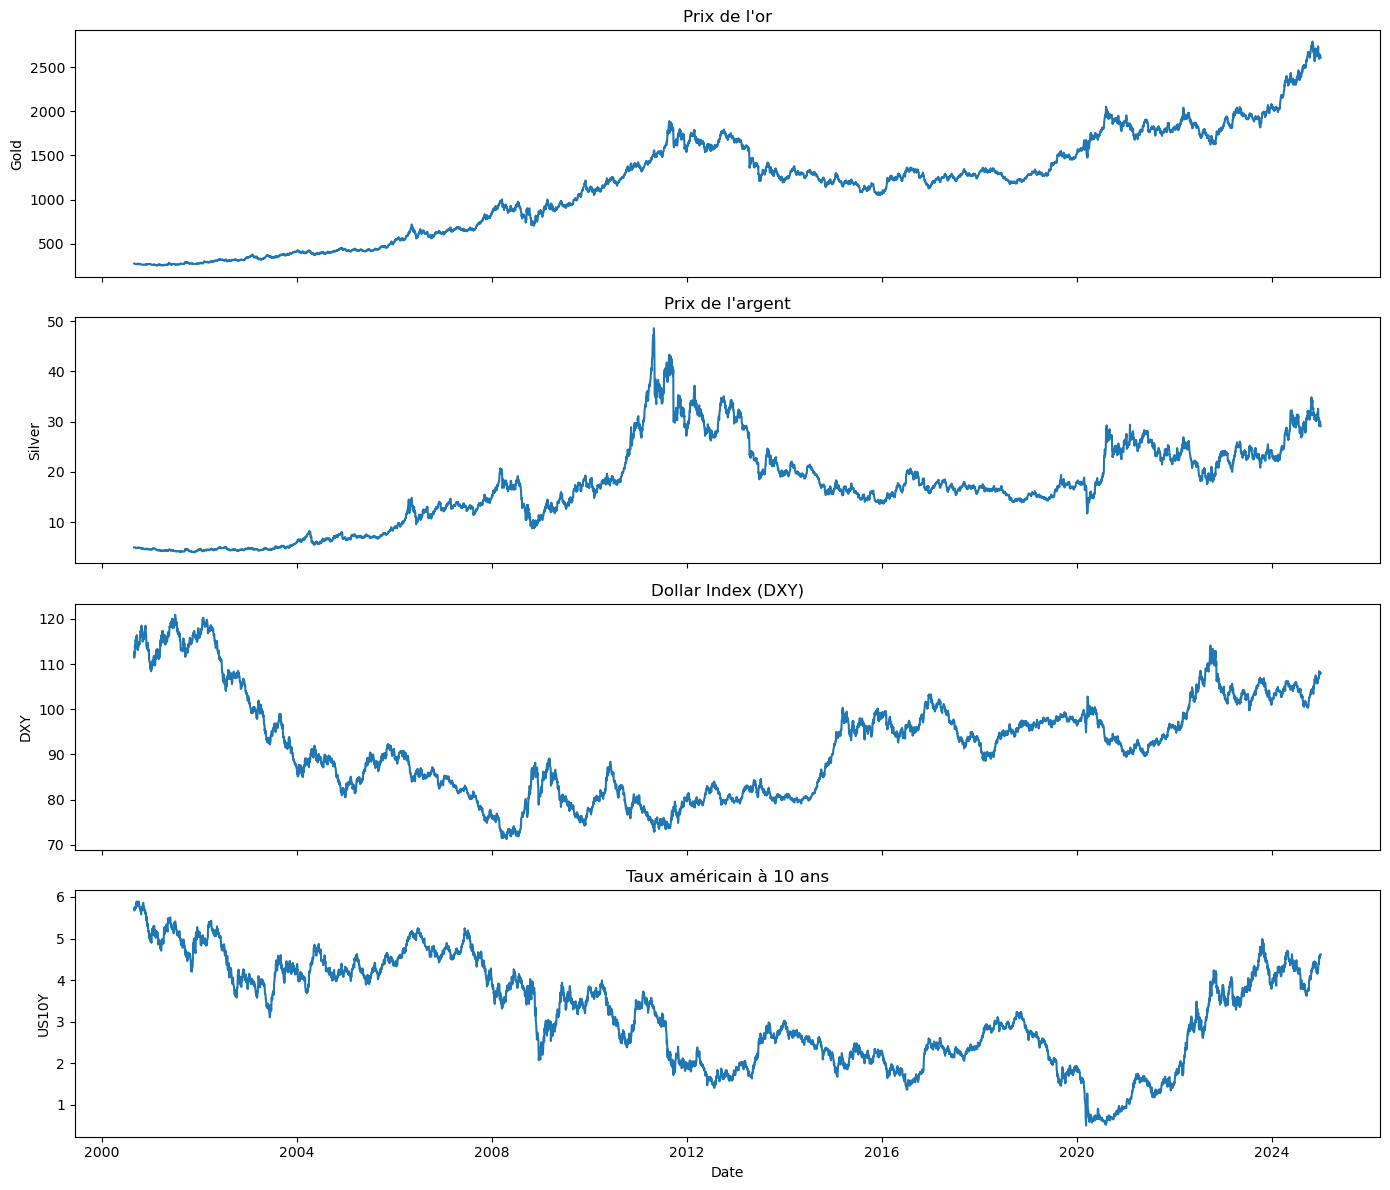

In [74]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# or
axes[0].plot(df_macro.index, df_macro["gold"])
axes[0].set_title("Prix de l'or")
axes[0].set_ylabel("Gold")

# argent
axes[1].plot(df_macro.index, df_macro["silver"])
axes[1].set_title("Prix de l'argent")
axes[1].set_ylabel("Silver")

# dollar index
axes[2].plot(df_macro.index, df_macro["dxy"])
axes[2].set_title("Dollar Index (DXY)")
axes[2].set_ylabel("DXY")

# taux US 10 ans
axes[3].plot(df_macro.index, df_macro["us10y"])
axes[3].set_title("Taux américain à 10 ans")
axes[3].set_ylabel("US10Y")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

### 3.2 Statistiques descriptives

In [75]:
df_macro[["gold", "silver", "us10y", "dxy"  , "dlog_dxy", "log_gold", "log_silver", "log_dxy" ,"dlog_gold", "dlog_silver", "dlog_dxy","dus10y" ]].describe().T

,count,mean,std,min,25%,50%,75%,max
gold,6148.0,1155.749934,581.713449,255.100006,625.475006,1231.299988,1612.400024,2788.500000
silver,6148.0,16.976377,8.515901,4.026000,11.226750,16.713000,22.647749,48.584000
us10y,6148.0,3.198513,1.225657,0.499000,2.181000,3.191500,4.224250,5.892000
dxy,6148.0,92.167253,11.269643,71.330002,82.309998,92.250000,99.162502,120.900002
dlog_dxy,6148.0,-0.000006,0.004865,-0.027169,-0.002773,0.000000,0.002746,0.025237
log_gold,6148.0,6.882858,0.636003,5.541656,6.438511,7.115826,7.385479,7.933259
log_silver,6148.0,2.674610,0.606214,1.392773,2.418299,2.816187,3.120060,3.883294
log_dxy,6148.0,4.516236,0.121080,4.267317,4.410493,4.524502,4.596760,4.794964
dlog_gold,6148.0,0.000366,0.010836,-0.098206,-0.004698,0.000425,0.006123,0.086432
dlog_silver,6148.0,0.000289,0.019700,-0.195457,-0.008368,0.000784,0.010053,0.121958


## 4. Tests de stationnarité

Les tests ADF et KPSS sont appliqués en niveau et en différences premières sur l'échantillon d'apprentissage. La convergence des deux diagnostics renforce la robustesse des conclusions.

### 4.1 Tests ADF et KPSS : niveaux

In [76]:
level_table_macro = stationarity_table(
df_macro_train[[
        "log_gold",
        "log_silver",
        "log_dxy",
        "us10y"
    ]])

level_table_macro

,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,2.111435,0.992942,Non stationnaire,9.512348,0.01,Non stationnaire
log_silver,0.585461,0.843773,Non stationnaire,8.123697,0.01,Non stationnaire
log_dxy,-0.642119,0.436968,Non stationnaire,3.427784,0.01,Non stationnaire
us10y,-1.548359,0.114246,Non stationnaire,8.711835,0.01,Non stationnaire


### 4.2 Tests ADF et KPSS : différences premières

In [77]:
diff_table_macro = stationarity_table(
    df_macro_train[[
        "dlog_gold",
        "dlog_silver",
        "dlog_dxy",
        "dus10y"]])

diff_table_macro

,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
dlog_gold,-20.852523,0.0,Stationnaire,0.239962,0.1,Stationnaire
dlog_silver,-67.060214,0.0,Stationnaire,0.150871,0.1,Stationnaire
dlog_dxy,-19.678731,0.0,Stationnaire,0.291111,0.1,Stationnaire
dus10y,-48.639072,0.0,Stationnaire,0.043327,0.1,Stationnaire


Les quatre séries en niveau (`log_gold`, `log_silver`, `log_dxy`, `us10y`) sont non stationnaires I(1). 
Leurs différences premières sont stationnaires. Le système est donc candidat à l'analyse de cointégration multivariée.

## 5. Sélection du nombre de retards

### 5.1 Critères d'information 

In [78]:
train_diff_macro = df_macro_train[[
    "dlog_gold",
    "dlog_silver",
    "dlog_dxy",
    "dus10y"]]

train_diff_macro_clean = (
    train_diff_macro
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy())

sel_macro = VAR(train_diff_macro_clean).select_order(maxlags=10,trend="c")

sel_macro.summary()

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-34.15,-34.15*,1.472e-15,-34.15*
1,-34.16,-34.13,1.462e-15,-34.15
2,-34.16*,-34.11,1.456e-15*,-34.14
3,-34.16,-34.08,1.461e-15,-34.13
4,-34.16,-34.06,1.463e-15,-34.12
5,-34.15,-34.03,1.469e-15,-34.11
6,-34.15,-34.00,1.475e-15,-34.10
7,-34.15,-33.98,1.479e-15,-34.09
8,-34.15,-33.95,1.478e-15,-34.08
9,-34.15,-33.93,1.477e-15,-34.07


In [79]:
from scipy.stats import chi2
max_p = 5

k = train_diff_macro_clean.shape[1]
df_lr = k * k

models_macro = {
    p: VAR(train_diff_macro_clean).fit(p)
    for p in range(1, max_p + 1)}

results = []
for p in range(2, max_p + 1):
    ll_p = models_macro[p].llf
    ll_p_1 = models_macro[p - 1].llf

    LR_stat = 2 * (ll_p - ll_p_1)
    p_value = 1 - chi2.cdf(LR_stat, df_lr)

    results.append({
        "Test": f"VAR({p-1}) vs VAR({p})",
        "H0": f"VAR({p-1}) suffit",
        "H1": f"VAR({p}) améliore le modèle",
        "LR_stat": round(LR_stat, 4),
        "df": df_lr,
        "p_value": round(p_value, 4),
        "Décision (5%)": "Rejet H0" if p_value < 0.05 else "Non-rejet H0"
    })

lr_table_macro = pd.DataFrame(results)
display(lr_table_macro)

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,Test,H0,H1,LR_stat,df,p_value,Décision (5%)
0,VAR(1) vs VAR(2),VAR(1) suffit,VAR(2) améliore le modèle,28.6616,16,0.0263,Rejet H0
1,VAR(2) vs VAR(3),VAR(2) suffit,VAR(3) améliore le modèle,-3.3837,16,1.0000,Non-rejet H0
2,VAR(3) vs VAR(4),VAR(3) suffit,VAR(4) améliore le modèle,8.6547,16,0.9269,Non-rejet H0
3,VAR(4) vs VAR(5),VAR(4) suffit,VAR(5) améliore le modèle,-12.3102,16,1.0000,Non-rejet H0


Le test LR compare des VAR emboîtés sur les différences premières. Le lag retenu (`final_lag`) est celui qui minimise les critères de selection de p tout en satisfaisant les critères de stabilité et de blancheur des résidus.

## 6. Analyse de cointégration multivariée

### 6.1 Test de Johansen 

#### 6.1.1 Spécification retenue

Le test de la trace de Johansen est appliqué avec :
- `det_order = 0` : constante restreinte dans la relation de cointégration
- `k_ar_diff = 1` : nombre de retards en différences (cohérent avec la sélection de la section 5)
- `deterministic = "co"` lors de l'estimation VECM

In [80]:
def johansen_all_specs(data, variables, det_orders=(0, 1), k_ar_diffs=(0, 1, 2), signif_index=1):

    results = []
    if isinstance(data, dict):
        data_dict = data
    else:
        data_dict = {"Global": data}
    for label, df_raw in data_dict.items():
        df = (
            df_raw[variables]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .copy())

        for det_order in det_orders:
            for k_ar_diff in k_ar_diffs:
                try:
                    joh = coint_johansen(df, det_order=det_order, k_ar_diff=k_ar_diff)
                    rank = 0
                    for r in range(len(joh.lr1)):
                        trace_stat = joh.lr1[r]
                        critical_value = joh.cvt[r, signif_index]
                        if trace_stat > critical_value:
                            rank = r + 1
                        else:
                            break

                    results.append({
                        "Sample": label,
                        "Variables": ", ".join(variables),
                        "det_order": det_order,
                        "k_ar_diff": k_ar_diff,
                        "Rank retenu": rank,
                        "Trace r=0": round(joh.lr1[0], 4),
                        "Critique r=0 (5%)": round(joh.cvt[0, signif_index], 4),
                        "Cointegration": "Oui" if rank >= 1 else "Non"})

                except Exception as e:
                    results.append({
                        "Sample": label,
                        "Variables": ", ".join(variables),
                        "det_order": det_order,
                        "k_ar_diff": k_ar_diff,
                        "Rank retenu": np.nan,
                        "Trace r=0": np.nan,
                        "Critique r=0 (5%)": np.nan,
                        "Cointegration": f"Erreur : {e}"})

    return pd.DataFrame(results)

In [81]:
variables_coint = ["log_gold", "log_silver", "log_dxy", "us10y"]

johansen_multivar_specs = johansen_all_specs(
    data=df_macro_train,
    variables=variables_coint,
    det_orders=(0,),
    k_ar_diffs=(1,),
    signif_index=1)

display(johansen_multivar_specs)

,Sample,Variables,det_order,k_ar_diff,Rank retenu,Trace r=0,Critique r=0 (5%),Cointegration
0,Global,"log_gold, log_silver, log_dxy, us10y",0,1,0,36.6668,47.8545,Non


Le test de la trace indique si au moins une relation de cointégration existe entre les quatre variables. Un rang r ≥ 1 signifie qu'il existe une combinaison linéaire stationnaire de `log_gold`, `log_silver`, `log_dxy` et `us10y` ou encore un équilibre de long terme conditionnel aux facteurs macro.

### 6.2 Engle-Granger multivarié 

Le test d'Engle-Granger est adapté au cadre multivarié : `log_gold` est régressé sur les trois autres variables par MCO ; les résidus de long terme sont soumis au test ADF.

In [82]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

data_eg_macro = ( df_macro_train[[
        "log_gold",
        "log_silver",
        "log_dxy",
        "us10y"
    ]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = sm.add_constant(
    data_eg_macro[[
        "log_silver",
        "log_dxy",
        "us10y" ]]
)

y = data_eg_macro["log_gold"]
long_run_model = sm.OLS(y, X).fit()
residuals = long_run_model.resid

adf_stat, pvalue, usedlag, nobs, crit, icbest = adfuller(residuals, regression="c", autolag="AIC")

eg_macro_result = pd.DataFrame([{
    "Méthode": "Engle-Granger multivarié",
    "Hypothèse nulle": "Absence de cointégration",
    "Statistique ADF": round(adf_stat, 4),
    "p-value ADF": round(pvalue, 4),
    "Retards utilisés": usedlag,
    "Nombre d'observations": nobs,
    "Seuil critique 1%": round(crit["1%"], 4),
    "Seuil critique 5%": round(crit["5%"], 4),
    "Seuil critique 10%": round(crit["10%"], 4),
    "Décision": "Rejet H0" if pvalue < 0.05 else "Non-rejet H0",
    "Conclusion": "Cointégration" if pvalue < 0.05 else "Pas de cointégration"
}])

display(eg_macro_result)

,Méthode,Hypothèse nulle,Statistique ADF,p-value ADF,Retards utilisés,Nombre d'observations,Seuil critique 1%,Seuil critique 5%,Seuil critique 10%,Décision,Conclusion
0,Engle-Granger multivarié,Absence de cointégration,-4.025,0.0013,19,4283,-3.4319,-2.8622,-2.5671,Rejet H0,Cointégration


## 7. Analyse de cointégration sur épisodes spécifiques

La cointégration peut être instable dans le temps : présente sur certains régimes macroéconomiques et absente sur d'autres. Une analyse rolling et par sous-périodes permet de localiser les épisodes où la relation de long terme est active.

### 7.1 Identification des épisodes

#### Rolling Engle-Granger multivarié

Fenêtre glissante de 1 000 observations sur `log_gold ~ log_silver + log_dxy + us10y`.

,Start,End,Duration_days
0,2013-01-18,2017-09-01,1687
1,2008-12-04,2010-02-03,426
2,2006-07-19,2007-09-10,418
3,2022-03-15,2023-03-02,352
4,2004-11-29,2005-09-15,290
5,2021-05-27,2022-01-07,225
6,2018-08-03,2019-03-07,216
7,2008-01-30,2008-08-20,203
8,2024-10-02,2024-12-27,86
9,2007-09-20,2007-12-05,76


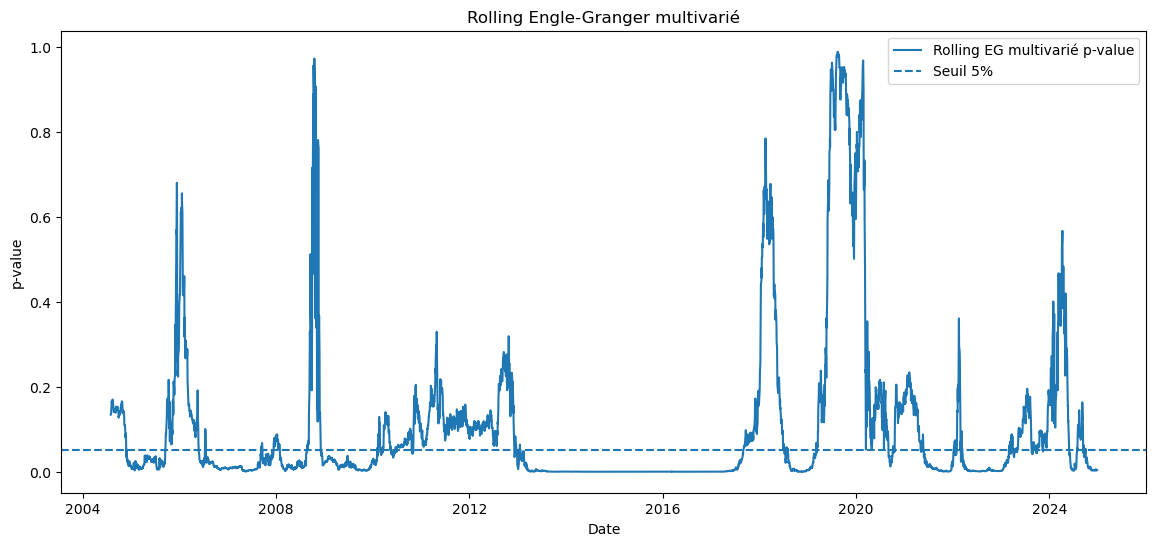

In [83]:
window = 1000

rolling_rows = []

data_roll = (
    df_macro[["log_gold", "log_silver", "log_dxy", "us10y"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

for i in range(window, len(data_roll)):
    sample = data_roll.iloc[i-window:i]
    try:
        X = sm.add_constant(sample[["log_silver", "log_dxy", "us10y"]])
        y = sample["log_gold"]
        model = sm.OLS(y, X).fit()
        residuals = model.resid
        adf_stat, p_value, *_ = adfuller(residuals)

        rolling_rows.append({
            "Date": sample.index[-1],
            "ADF_stat": adf_stat,
            "p_value": p_value})

    except Exception:
        rolling_rows.append({
            "Date": sample.index[-1],
            "ADF_stat": np.nan,
            "p_value": np.nan})

rolling_multi = pd.DataFrame(rolling_rows).set_index("Date")
threshold = 0.05
rolling_multi["cointegrated"] = rolling_multi["p_value"] < threshold

intervals_multi = []
start = None

for date, row in rolling_multi.iterrows():
    if row["cointegrated"] and start is None:
        start = date
    elif (not row["cointegrated"]) and start is not None:
        end = date
        intervals_multi.append((start, end))
        start = None

if start is not None:
    intervals_multi.append((start, rolling_multi.index[-1]))

intervals_multi_df = pd.DataFrame(intervals_multi, columns=["Start", "End"])

intervals_multi_df["Duration_days"] = (
    intervals_multi_df["End"] - intervals_multi_df["Start"]
).dt.days

intervals_multi_df = intervals_multi_df.sort_values( by="Duration_days", ascending=False ).reset_index(drop=True)

display(intervals_multi_df)

plt.figure(figsize=(14, 6))

plt.plot( rolling_multi.index, rolling_multi["p_value"], label="Rolling EG multivarié p-value")

plt.axhline(0.05, linestyle="--", label="Seuil 5%")

plt.title("Rolling Engle-Granger multivarié")
plt.ylabel("p-value")
plt.xlabel("Date")
plt.legend()
plt.show()

#### Test de Johansen par sous-périodes

In [84]:
periods = {
    "pre_crisis_global"      : df_macro.loc["2000":"2007-06"],
    "global_financial_crisis": df_macro.loc["2007-07":"2009"],
    "post_crisis_QE"         : df_macro.loc["2010":"2014"],
    "commodity_stress"       : df_macro.loc["2015":"2016"],
    "late_cycle_expansion"   : df_macro.loc["2017":"2019"],
    "covid_shock"            : df_macro.loc["2020":"2022"],}

In [85]:
johansen_subperiods = johansen_all_specs(
    data=periods,
    variables=["log_gold", "log_silver", "log_dxy", "us10y"],
    det_orders=(0,),
    k_ar_diffs=(1,),
    signif_index=1)

display(johansen_subperiods)

,Sample,Variables,det_order,k_ar_diff,Rank retenu,Trace r=0,Critique r=0 (5%),Cointegration
0,pre_crisis_global,"log_gold, log_silver, log_dxy, us10y",0,1,0,37.7741,47.8545,Non
1,global_financial_crisis,"log_gold, log_silver, log_dxy, us10y",0,1,0,34.0123,47.8545,Non
2,post_crisis_QE,"log_gold, log_silver, log_dxy, us10y",0,1,0,44.4768,47.8545,Non
3,commodity_stress,"log_gold, log_silver, log_dxy, us10y",0,1,0,46.6248,47.8545,Non
4,late_cycle_expansion,"log_gold, log_silver, log_dxy, us10y",0,1,0,37.0670,47.8545,Non
5,covid_shock,"log_gold, log_silver, log_dxy, us10y",0,1,1,48.1595,47.8545,Oui


### 7.3 Test de Johansen sur l'épisode retenu : tets de Johansen local

In [86]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

longest_multi = intervals_multi_df.sort_values( by="Duration_days", ascending=False).iloc[0]
start_multi = longest_multi["Start"]
end_multi   = longest_multi["End"]

print("Épisode retenu :", start_multi.date(), "→", end_multi.date())
print("Durée calendaire :", longest_multi["Duration_days"], "jours")

vars_multi = ["log_gold", "log_silver", "log_dxy", "us10y"]
episode_multi = (
    df_macro.loc[start_multi:end_multi, vars_multi]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print("Nombre d'observations :", len(episode_multi))

joh_local_multi = coint_johansen( episode_multi, det_order=0, k_ar_diff=1)

joh_local_multi_table = pd.DataFrame({
    "Hypothèse": [f"r <= {i}" for i in range(len(joh_local_multi.lr1))],
    "Trace stat": joh_local_multi.lr1,
    "Crit 5%": joh_local_multi.cvt[:, 1],
    "Décision": [
        "Rejet H0" if joh_local_multi.lr1[i] > joh_local_multi.cvt[i, 1]
        else "Non-rejet H0"
        for i in range(len(joh_local_multi.lr1))
    ]
})

display(joh_local_multi_table)

rank = 0
for i in range(len(joh_local_multi.lr1)):
    if joh_local_multi.lr1[i] > joh_local_multi.cvt[i, 1]:
        rank = i + 1
    else:
        break

print("Rang de cointégration retenu :", rank)

Épisode retenu : 2013-01-18 → 2017-09-01
Durée calendaire : 1687 jours
Nombre d'observations : 1165


,Hypothèse,Trace stat,Crit 5%,Décision
0,r <= 0,40.032232,47.8545,Non-rejet H0
1,r <= 1,24.841226,29.7961,Non-rejet H0
2,r <= 2,10.427296,15.4943,Non-rejet H0
3,r <= 3,1.765538,3.8415,Non-rejet H0


Rang de cointégration retenu : 0


### Conclusion : instabilité et régimes de cointégration

L'introduction du dollar et des taux allonge et multiplie les épisodes de cointégration détectés. Cela confirme que les facteurs macro jouent un rôle structurant dans la relation de long terme. Le VECM est estimé sur le plus long épisode identifié.

## 8. Estimation du VECM sur l'épisode de cointégration

### 8.1 Justification du VECM local

La cointégration n'est pas permanente sur l'ensemble de la période. L'approche conditionnelle consiste à estimer un VECM uniquement sur la fenêtre où la cointégration est établie. Cela permet d'étudier localement les mécanismes d'ajustement et de transmission macro-financière sans prétendre à une relation structurelle stable sur toute la période.

### 8.2 Spécification du modèle et données de l'épisode

In [87]:
best_interval_multi = (
    intervals_multi_df
    .sort_values("Duration_days", ascending=False)
    .iloc[0])
start = best_interval_multi["Start"]
end = best_interval_multi["End"]
print("Start :", start)
print("End :", end)

vecm_data_multi = df_macro.loc[
    start:end,
    ["log_gold", "log_silver", "log_dxy", "us10y"]
].dropna().copy()
print("Shape :", vecm_data_multi.shape)

Start : 2013-01-18 00:00:00
End : 2017-09-01 00:00:00
Shape : (1165, 4)


In [88]:
vecm_diff_multi = vecm_data_multi.diff().dropna().copy()
level_table_vecm_multi = stationarity_table(vecm_data_multi)
diff_table_vecm_multi  = stationarity_table(vecm_diff_multi)

print("Niveaux")
display(level_table_vecm_multi)
print("Différences premières")
display(diff_table_vecm_multi)

Niveaux


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,-0.682628,0.419928,Non stationnaire,1.870174,0.01,Non stationnaire
log_silver,-1.297730,0.179518,Non stationnaire,2.963485,0.01,Non stationnaire
log_dxy,0.937911,0.907065,Non stationnaire,4.676919,0.01,Non stationnaire
us10y,-0.151829,0.631536,Non stationnaire,1.293842,0.01,Non stationnaire


Différences premières


,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion
Série,,,,,,
log_gold,-18.707730,3.616496e-29,Stationnaire,0.293111,0.1,Stationnaire
log_silver,-12.822455,2.201358e-23,Stationnaire,0.295817,0.1,Stationnaire
log_dxy,-35.129554,0.000000e+00,Stationnaire,0.224640,0.1,Stationnaire
us10y,-35.086668,0.000000e+00,Stationnaire,0.095089,0.1,Stationnaire


In [89]:
print("Période VECM :", start.date(), "→", end.date())
print("Nombre d'observations :", len(vecm_data_multi))

Période VECM : 2013-01-18 → 2017-09-01
Nombre d'observations : 1165


### 8.3 Estimation du VECM

Le modèle retient :
- **rang de cointégration** : r = 1 (confirmé par le Johansen local, section 7.3)
- **k_ar_diff** : discuté en section 9 (diagnostics résidus)
- **composantes déterministes** : `deterministic = "co"` (constante dans la relation de cointégration)

#### 8.3.1 Relation de long terme β

In [90]:
from statsmodels.tsa.vector_ar.vecm import VECM, select_order, coint_johansen

vecm_model_multi = VECM(
    vecm_data_multi,
    k_ar_diff   = 1,
    coint_rank  = 1,
    deterministic = "co")
vecm_res_multi = vecm_model_multi.fit()
print(vecm_res_multi.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation log_gold
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1106      0.033      3.380      0.001       0.046       0.175
L1.log_gold      -0.0931      0.055     -1.702      0.089      -0.200       0.014
L1.log_silver     0.0033      0.032      0.102      0.919      -0.059       0.066
L1.log_dxy       -0.1277      0.073     -1.750      0.080      -0.271       0.015
L1.us10y         -0.0158      0.007     -2.141      0.032      -0.030      -0.001
Det. terms outside the coint. relation & lagged endog. parameters for equation log_silver
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1854      0.054      3.461      0.001       0.080       0.290
L1

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [91]:
beta_table_multi = pd.DataFrame({
    "Variable"  : vecm_data_multi.columns,
    "Beta"      : vecm_res_multi.beta[:, 0],
    "Std_Error" : vecm_res_multi.stderr_beta[:, 0],
    "t_stat"    : vecm_res_multi.tvalues_beta[:, 0],
    "p_value"   : vecm_res_multi.pvalues_beta[:, 0]})

display(beta_table_multi)

,Variable,Beta,Std_Error,t_stat,p_value
0,log_gold,1.000000,0.000000,0.000000,0.000000
1,log_silver,0.781910,0.352100,2.220708,0.026371
2,log_dxy,1.423702,0.777488,1.831157,0.067077
3,us10y,0.129747,0.131010,0.990362,0.321997


#### 8.3.2 Coefficients d'ajustement α

In [92]:
alpha_table_multi = pd.DataFrame({
    "Equation"  : [
        "dlog_gold",
        "dlog_silver",
        "dlog_dxy",
        "dus10y"
    ],
    "Alpha"      : vecm_res_multi.alpha[:, 0],
    "Std_Error"  : vecm_res_multi.stderr_alpha[:, 0],
    "t_stat"     : vecm_res_multi.tvalues_alpha[:, 0],
    "p_value"    : vecm_res_multi.pvalues_alpha[:, 0]})

display(alpha_table_multi)

,Equation,Alpha,Std_Error,t_stat,p_value
0,dlog_gold,-0.006879,0.002031,-3.386391,0.000708
1,dlog_silver,-0.011542,0.003325,-3.471336,0.000518
2,dlog_dxy,0.000055,0.000888,0.061923,0.950624
3,dus10y,0.012624,0.008778,1.438118,0.150401


#### 8.3.3 Relation normalisée et ECT

In [93]:
beta_norm_multi = ( vecm_res_multi.beta[:, 0] / vecm_res_multi.beta[0, 0])

b_gold = beta_norm_multi[0]
b_silver = beta_norm_multi[1]
b_dxy = beta_norm_multi[2]
b_us10y = beta_norm_multi[3]

print("Vecteur beta estimé :")
print(
    f"{b_gold:.4f} * log_gold "
    f"+ ({b_silver:.4f}) * log_silver "
    f"+ ({b_dxy:.4f}) * log_dxy "
    f"+ ({b_us10y:.4f}) * us10y = 0")

print("\nRelation de long terme normalisée sur log_gold :")

print(
    f"log_gold "
    f"+ ({b_silver:.4f}) * log_silver "
    f"+ ({b_dxy:.4f}) * log_dxy "
    f"+ ({b_us10y:.4f}) * us10y = 0")

print("\nForme réarrangée :")

print(
    f"log_gold = "
    f"{-b_silver:.4f} * log_silver "
    f"{-b_dxy:+.4f} * log_dxy "
    f"{-b_us10y:+.4f} * us10y")

Vecteur beta estimé :
1.0000 * log_gold + (0.7819) * log_silver + (1.4237) * log_dxy + (0.1297) * us10y = 0

Relation de long terme normalisée sur log_gold :
log_gold + (0.7819) * log_silver + (1.4237) * log_dxy + (0.1297) * us10y = 0

Forme réarrangée :
log_gold = -0.7819 * log_silver -1.4237 * log_dxy -0.1297 * us10y


In [94]:
beta_norm_multi = ( vecm_res_multi.beta[:, 0] / vecm_res_multi.beta[0, 0])

vecm_data_multi["ECT"] = (
    beta_norm_multi[0] * vecm_data_multi["log_gold"] +
    beta_norm_multi[1] * vecm_data_multi["log_silver"] +
    beta_norm_multi[2] * vecm_data_multi["log_dxy"] +
    beta_norm_multi[3] * vecm_data_multi["us10y"])

vecm_data_multi[["log_gold", "log_silver", "log_dxy", "us10y", "ECT"]].tail()

,log_gold,log_silver,log_dxy,us10y,ECT
Date,,,,,
2017-08-28,7.177553,2.858250,4.524069,2.159,16.133497
2017-08-29,7.180146,2.857734,4.525586,2.136,16.134862
2017-08-30,7.176331,2.856700,4.531308,2.143,16.139294
2017-08-31,7.182504,2.861057,4.529045,2.121,16.142797
2017-09-01,7.188790,2.874638,4.530554,2.157,16.166522


In [95]:
beta_table_multi["Bloc"] = "Long terme (beta)"
alpha_table_multi["Bloc"] = "Ajustement (alpha)"

beta_table_final_multi = beta_table_multi.rename(columns={ "Variable": "Nom", "Beta": "Coefficient"})

alpha_table_final_multi = alpha_table_multi.rename(columns={ "Equation": "Nom", "Alpha": "Coefficient"})

vecm_summary_table_multi = pd.concat([
    beta_table_final_multi[[
        "Bloc",
        "Nom",
        "Coefficient",
        "Std_Error",
        "t_stat",
        "p_value"]],
    alpha_table_final_multi[[
        "Bloc",
        "Nom",
        "Coefficient",
        "Std_Error",
        "t_stat",
        "p_value"]]

], axis=0).reset_index(drop=True)

display(vecm_summary_table_multi)

,Bloc,Nom,Coefficient,Std_Error,t_stat,p_value
0,Long terme (beta),log_gold,1.000000,0.000000,0.000000,0.000000
1,Long terme (beta),log_silver,0.781910,0.352100,2.220708,0.026371
2,Long terme (beta),log_dxy,1.423702,0.777488,1.831157,0.067077
3,Long terme (beta),us10y,0.129747,0.131010,0.990362,0.321997
4,Ajustement (alpha),dlog_gold,-0.006879,0.002031,-3.386391,0.000708
5,Ajustement (alpha),dlog_silver,-0.011542,0.003325,-3.471336,0.000518
6,Ajustement (alpha),dlog_dxy,0.000055,0.000888,0.061923,0.950624
7,Ajustement (alpha),dus10y,0.012624,0.008778,1.438118,0.150401


Le vecteur β donne la relation d'équilibre de long terme entre les quatre variables. Les coefficients d'ajustement α indiquent quelle(s) variable(s) corrigent les déviations à cet équilibre. 

Un α non significatif pour l'or confirme son rôle de *price leader* ; un α significatif pour l'argent confirme son rôle de *price follower*.

## 9. Normalité des résidus

In [99]:
log_cols_multi = ["log_gold", "log_silver", "log_dxy", "us10y"]

vecm_full_multi = VECM(vecm_data_multi[log_cols_multi], k_ar_diff=1, coint_rank=1, deterministic="co").fit()
print(vecm_full_multi.summary())

resid_multi = pd.DataFrame(vecm_full_multi.resid, columns=log_cols_multi)
diag_multi_rows = []

for col in log_cols_multi:
    lb = sm.stats.acorr_ljungbox(resid_multi[col], lags=[12], return_df=True)
    diag_multi_rows.append({
        "Série"   : f"{col} (résidus)",
        "LB stat" : round(lb["lb_stat"].values[0], 4),
        "p-value" : round(lb["lb_pvalue"].values[0], 4),
        "Décision": "Rejet H0" if lb["lb_pvalue"].values[0] < 0.05 else "Non-rejet H0"
    })

display(pd.DataFrame(diag_multi_rows))

Det. terms outside the coint. relation & lagged endog. parameters for equation log_gold
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1106      0.033      3.380      0.001       0.046       0.175
L1.log_gold      -0.0931      0.055     -1.702      0.089      -0.200       0.014
L1.log_silver     0.0033      0.032      0.102      0.919      -0.059       0.066
L1.log_dxy       -0.1277      0.073     -1.750      0.080      -0.271       0.015
L1.us10y         -0.0158      0.007     -2.141      0.032      -0.030      -0.001
Det. terms outside the coint. relation & lagged endog. parameters for equation log_silver
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1854      0.054      3.461      0.001       0.080       0.290
L1

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Série,LB stat,p-value,Décision
0,log_gold (résidus),16.5055,0.1692,Non-rejet H0
1,log_silver (résidus),20.1852,0.0637,Non-rejet H0
2,log_dxy (résidus),20.4462,0.0591,Non-rejet H0
3,us10y (résidus),13.3097,0.3469,Non-rejet H0


### 10. Re-estimation sur tout l'échantillon 

In [100]:
vecm_full_multi = VECM( vecm_data_multi[log_cols_multi], k_ar_diff=1, coint_rank=1, deterministic="co").fit()
print(vecm_full_multi.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation log_gold
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1106      0.033      3.380      0.001       0.046       0.175
L1.log_gold      -0.0931      0.055     -1.702      0.089      -0.200       0.014
L1.log_silver     0.0033      0.032      0.102      0.919      -0.059       0.066
L1.log_dxy       -0.1277      0.073     -1.750      0.080      -0.271       0.015
L1.us10y         -0.0158      0.007     -2.141      0.032      -0.030      -0.001
Det. terms outside the coint. relation & lagged endog. parameters for equation log_silver
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1854      0.054      3.461      0.001       0.080       0.290
L1

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [101]:
resid_multi = pd.DataFrame( vecm_full_multi.resid, columns=log_cols_multi)
diag_multi_rows = []
for col in log_cols_multi:
    lb = sm.stats.acorr_ljungbox(resid_multi[col], lags=[12], return_df=True)
    diag_multi_rows.append({
        "Série" : f"{col} (résidus)",
        "LB stat" : round(lb["lb_stat"].values[0], 4),
        "p-value" : round(lb["lb_pvalue"].values[0], 4),
        "Décision": "Rejet H0" if lb["lb_pvalue"].values[0] < 0.05 else "Non-rejet H0"})

display(pd.DataFrame(diag_multi_rows))

,Série,LB stat,p-value,Décision
0,log_gold (résidus),16.5055,0.1692,Non-rejet H0
1,log_silver (résidus),20.1852,0.0637,Non-rejet H0
2,log_dxy (résidus),20.4462,0.0591,Non-rejet H0
3,us10y (résidus),13.3097,0.3469,Non-rejet H0


Les p-values des tests de Ljung–Box sont supérieures à 0,05 pour les résidus des quatre équations (or, argent, dollar, taux US 10 ans) : l'hypothèse nulle d'absence d'autocorrélation ne peut être rejetée au seuil de 5 %. 

Le modèle capture correctement la dépendance temporelle des séries et le VECM à k_ar_diff = 1 est retenu comme globalement adéquat. 

### 11. Fonctions de réponse impulsionnelle : VECM multivarié

### 11.1 Generalized IRF (Pesaran-Shin) 

In [119]:
Sigma = np.array(vecm_full_multi.sigma_u)
n_steps = 20
ma_mats = vecm_full_multi.ma_rep(n_steps)
variables = ["log_gold", "log_silver", "log_dxy", "us10y"]
n = len(variables)
girfs = np.zeros((n_steps + 1, n, n))

for h in range(n_steps + 1):
    Phi_h = ma_mats[h]
    for j in range(n):
        e_j = np.zeros(n)
        e_j[j] = 1
        sigma_jj = Sigma[j, j]
        girfs[h, :, j] = (Phi_h @ Sigma @ e_j) / np.sqrt(sigma_jj)

horizon = np.arange(n_steps + 1)

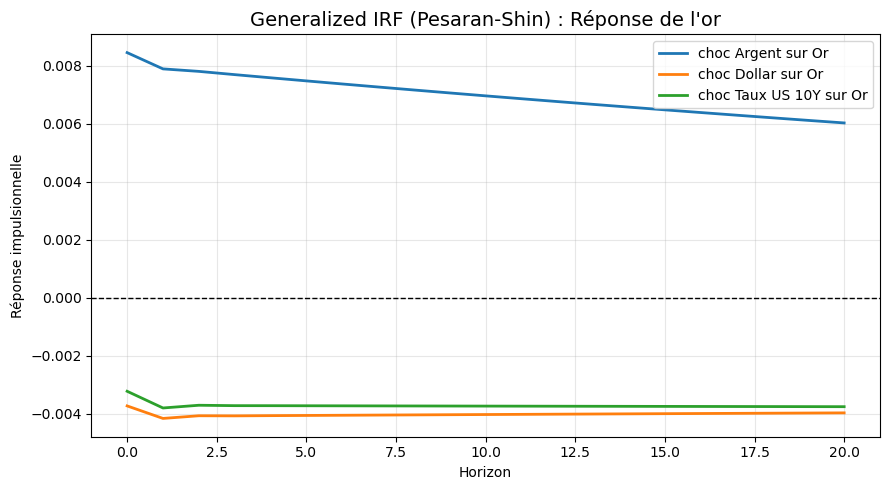

In [103]:
plt.figure(figsize=(9, 5))

for impulse, label in [
    ("log_silver", "choc Argent sur Or"),
    ("log_dxy", "choc Dollar sur Or"),
    ("us10y", "choc Taux US 10Y sur Or"),]:

    i_impulse  = variables.index(impulse)
    i_response = variables.index("log_gold")
    plt.plot(horizon, girfs[:, i_response, i_impulse], linewidth=2, label=label)

plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.title("Generalized IRF (Pesaran-Shin) : Réponse de l'or", fontsize=14)
plt.xlabel("Horizon")
plt.ylabel("Réponse impulsionnelle")
plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

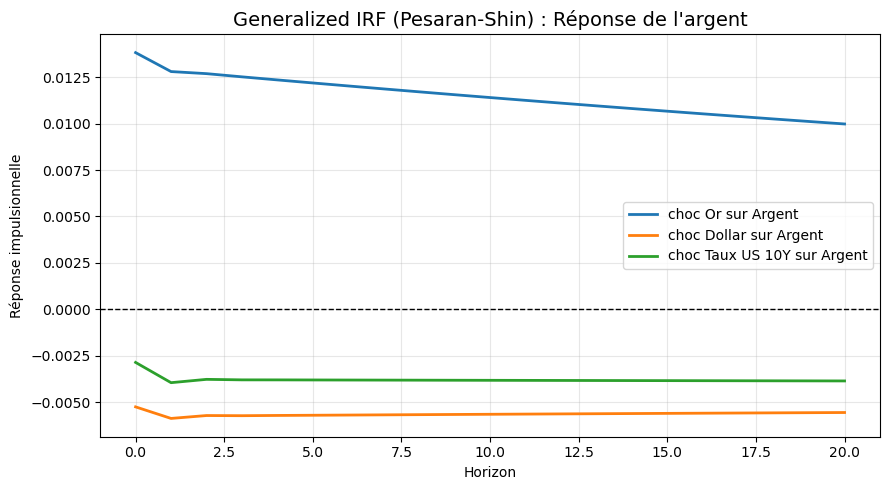

In [104]:
plt.figure(figsize=(9, 5))

for impulse, label in [
    ("log_gold", "choc Or sur Argent"),
    ("log_dxy", "choc Dollar sur Argent"),
    ("us10y", "choc Taux US 10Y sur Argent"),]:

    i_impulse = variables.index(impulse)
    i_response = variables.index("log_silver")
    plt.plot(horizon, girfs[:, i_response, i_impulse], linewidth=2, label=label)

plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.title("Generalized IRF (Pesaran-Shin) : Réponse de l'argent", fontsize=14)
plt.xlabel("Horizon")
plt.ylabel("Réponse impulsionnelle")
plt.legend(frameon=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation macro-financière des chocs

Les fonctions de réponse impulsionnelle obtenues sont économiquement cohérentes :

- **Choc Dollar sur Or** : un choc positif sur le DXY entraîne une réponse négative du prix de l'or confirmant la relation inverse dollar–or.
- **Choc Taux US 10Y** : une hausse des taux pèse sur le prix de l'or via l'augmentation du coût d'opportunité.
- **Choc Or sur Argent** : la réponse positive de l'argent à un choc sur l'or reflète l'interdépendance entre les deux métaux sur l'épisode de cointégration.
Les réponses sont lisses et convergentes sans explosion ce qui est cohérent avec la stabilité locale du VECM.

---

## Conclusion de la partie multivariée

Le cadre macro-financier à quatre variables enrichit substantiellement l'analyse bivariée :

1. **Diagnostic de cointégration amélioré** : la cointégration est plus fréquente et plus longue une fois le dollar et les taux contrôlés ce qui confirme leur rôle de facteurs de *pricing communs*.

2. **Relation de long terme conditionnelle** : le vecteur β estimé sur l'épisode principal livre une relation structurelle économiquement plausible entre or, argent, dollar et taux.

3. **Hiérarchie d'ajustement** : les coefficients α confirment que l'or joue le rôle de *price leader* et l'argent celui de *price follower*.

4. **Principales limites** : l'approche reste conditionnelle (fenêtre sélectionnée a posteriori) ; les inférences ne peuvent pas être généralisées à l'ensemble de la période. Le VECM est conservé comme outil exploratoire local et non comme modèle de prévision central.

**Remarque : La suite du notebook présente le VAR multivarié sur les différences premières.**


## 12. VAR multivarié sur les différences premières

### 12.1 Estimation du VAR multivarié

In [106]:
def recursive_one_step_forecast_var_multi(diff_df, log_df, start_idx, end_idx, p):
    pred_diff, act_diff, pred_log, act_log = [], [], [], []
    idx = []

    for t in range(start_idx, end_idx):
        history = diff_df.iloc[:t]
        model = VAR(history).fit(p)
        fc = model.forecast(history.values[-p:], steps=1)[0]

        date = diff_df.index[t]
        prev_log = log_df.loc[diff_df.index[t - 1]].values

        pred_diff.append(fc)
        act_diff.append(diff_df.iloc[t].values)
        pred_log.append(prev_log + fc)
        act_log.append(log_df.loc[date].values)
        idx.append(date)

    pred_diff = pd.DataFrame(pred_diff, index=idx, columns=diff_df.columns)
    act_diff = pd.DataFrame(act_diff,  index=idx, columns=diff_df.columns)
    pred_log = pd.DataFrame(pred_log,  index=idx, columns=log_df.columns)
    act_log = pd.DataFrame(act_log,   index=idx, columns=log_df.columns)

    return pred_diff, act_diff, pred_log, act_log

In [108]:
final_var_multi = VAR(train_diff_macro_clean).fit(1)
print(final_var_multi.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     20:51:31
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -34.1308
Nobs:                     4302.00    HQIC:                  -34.1500
Log likelihood:           49082.0    FPE:                1.45989e-15
AIC:                     -34.1604    Det(Omega_mle):     1.45313e-15
--------------------------------------------------------------------
Results for equation dlog_gold
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000361         0.000174            2.077           0.038
L1.dlog_gold          -0.037385         0.025141           -1.487           0.137
L1.dlog_silver        -0.004726         0.014146    

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### 12.2 Validation hors échantillon du VAR multivarié

In [110]:
diff_cols_multi = ["dlog_gold", "dlog_silver", "dlog_dxy", "dus10y"]
log_cols_var_multi = ["log_gold", "log_silver", "log_dxy", "us10y"]
df_macro_all = pd.concat([df_macro_train, df_macro_val, df_macro_test]).sort_index()
diff_df_multi = (df_macro_all[diff_cols_multi].replace([np.inf, -np.inf], np.nan).dropna())
log_df_multi = (df_macro_all[log_cols_var_multi].replace([np.inf, -np.inf], np.nan).dropna())
val_start_var_multi = diff_df_multi.index.searchsorted(df_macro_val.index[0])
val_end_var_multi   = diff_df_multi.index.searchsorted(df_macro_val.index[-1], side="right")

lag_var_multi = 2
candidates_multi = [lag_var_multi]  # on peut aussi tester d'autres lags pour voir la sensibilité
val_tables_multi = []

for p in candidates_multi:
    pd_diff, ad_diff, pd_log, ad_log = recursive_one_step_forecast_var_multi(
        diff_df = diff_df_multi,
        log_df = log_df_multi,
        start_idx = val_start_var_multi,
        end_idx = val_end_var_multi,
        p = p)

    pred_lev = np.exp(pd_log[["log_gold", "log_silver", "log_dxy"]])
    act_lev = np.exp(ad_log[["log_gold", "log_silver", "log_dxy"]])

    m = level_metrics(pred_lev, act_lev)
    m["Lag"] = p
    val_tables_multi.append(m.reset_index())

val_metrics_multi = pd.concat(val_tables_multi).reset_index(drop=True)
print("Métriques validation — VAR multivarié")
display(val_metrics_multi)

pred_log_val_var_multi = pd_log
act_log_val_var_multi = ad_log

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

Métriques validation — VAR multivarié


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Variable,RMSE,MAE,MAPE_%,Lag
0,log_gold,15.357960,10.036283,0.648294,2
1,log_silver,0.412755,0.241015,1.248696,2
2,log_dxy,0.353238,0.270164,0.284338,2


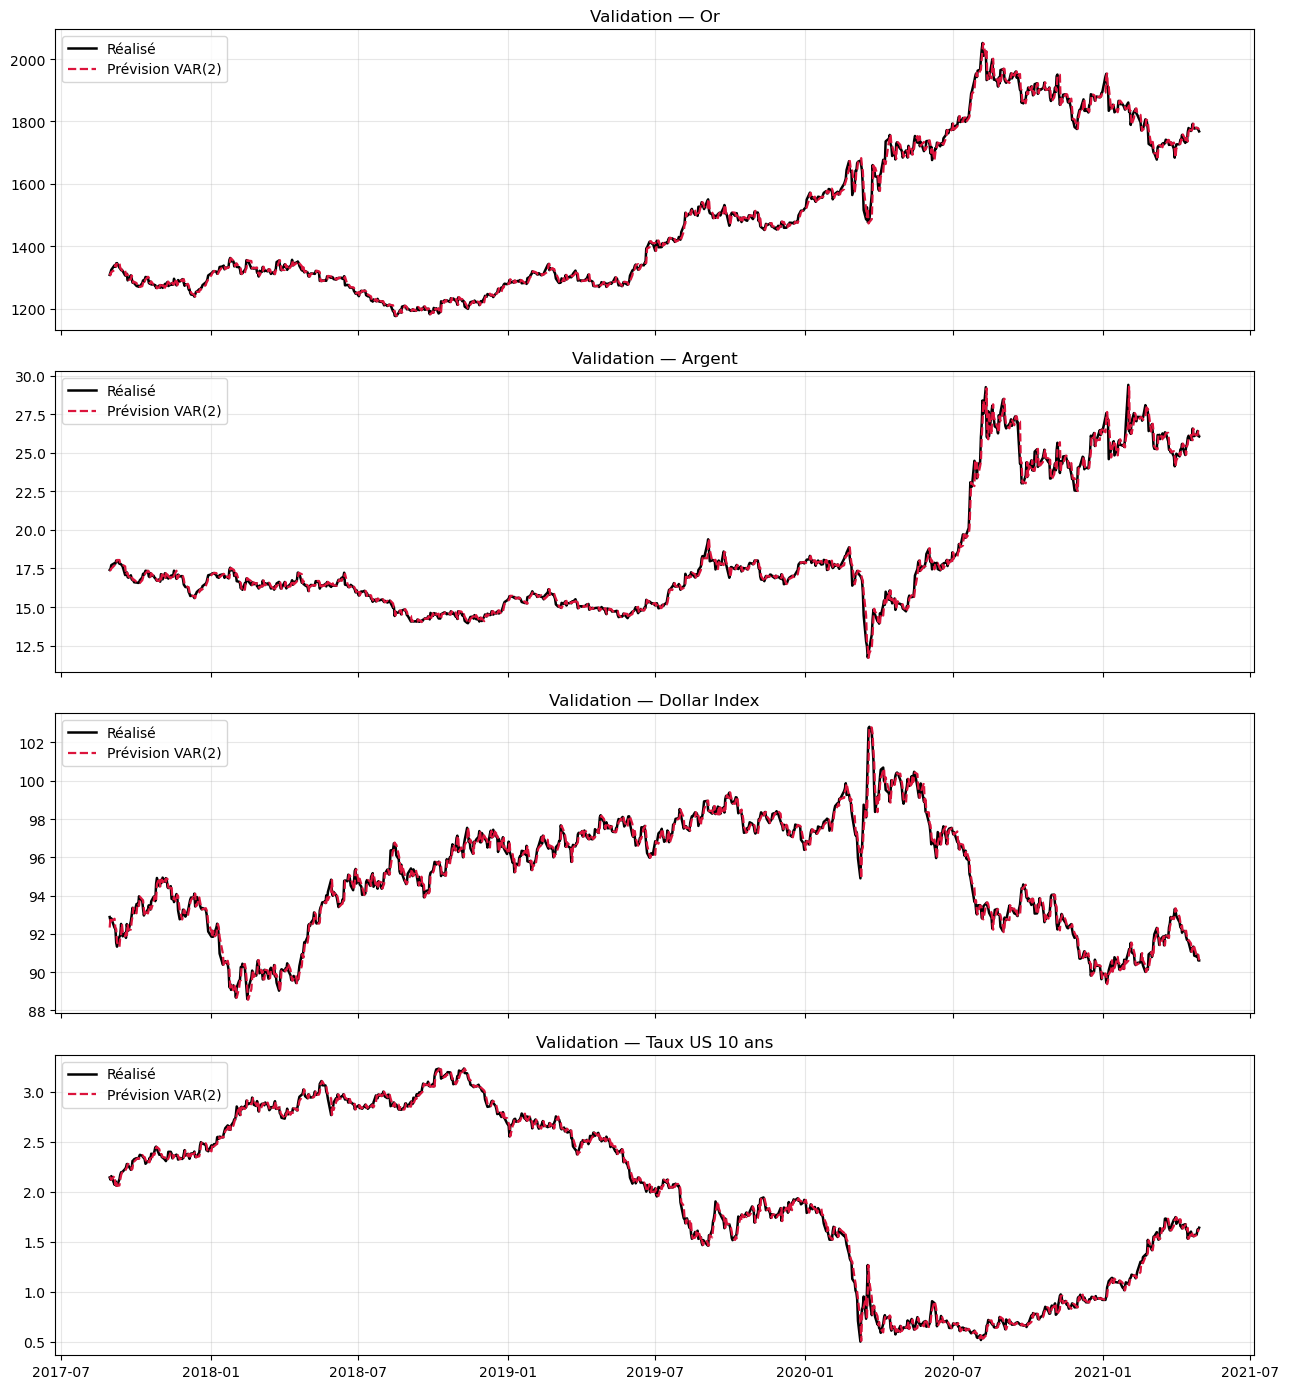

In [111]:
labels_var = {
    "log_gold" : "Or",
    "log_silver": "Argent",
    "log_dxy" : "Dollar Index",
    "us10y" : "Taux US 10 ans"}

fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

for i, col in enumerate(log_cols_var_multi):
    if col == "us10y":
        pred_plot = pred_log_val_var_multi[col]
        act_plot  = act_log_val_var_multi[col]
    else:
        pred_plot = np.exp(pred_log_val_var_multi[col])
        act_plot  = np.exp(act_log_val_var_multi[col])

    axes[i].plot(act_plot.index,  act_plot,  label="Réalisé", linewidth=1.8, color="black")
    axes[i].plot(pred_plot.index, pred_plot, label=f"Prévision VAR({lag_var_multi})",linewidth=1.6, linestyle="--", color="crimson")
    axes[i].set_title(f"Validation — {labels_var[col]}")
    axes[i].legend(loc="upper left")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 12.3 Évaluation sur l'échantillon de test du VAR multivarié

In [112]:
test_start_var_multi = diff_df_multi.index.searchsorted(df_macro_test.index[0])
test_end_var_multi   = diff_df_multi.index.searchsorted(df_macro_test.index[-1], side="right")

pd_diff_t, ad_diff_t, pd_log_t, ad_log_t = recursive_one_step_forecast_var_multi(
    diff_df = diff_df_multi,
    log_df = log_df_multi,
    start_idx = test_start_var_multi,
    end_idx = test_end_var_multi,
    p = lag_var_multi)

pred_lev_test_multi = np.exp(pd_log_t[["log_gold", "log_silver", "log_dxy"]])
act_lev_test_multi = np.exp(ad_log_t[["log_gold", "log_silver", "log_dxy"]])
test_metrics_multi = level_metrics(pred_lev_test_multi, act_lev_test_multi)
test_metrics_multi["Lag"] = lag_var_multi

print("Métriques test : VAR multivarié")
display(test_metrics_multi)

pred_log_test_var_multi = pd_log_t
act_log_test_var_multi  = ad_log_t

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

Métriques test : VAR multivarié


C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates

,RMSE,MAE,MAPE_%,Lag
Variable,,,,
log_gold,18.748286,13.858826,0.687117,2
log_silver,0.459228,0.334595,1.359002,2
log_dxy,0.468480,0.345881,0.336688,2


In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(13, 14), sharex=True)

for i, col in enumerate(log_cols_var_multi):
    if col == "us10y":
        pred_plot = pred_log_test_var_multi[col]
        act_plot  = act_log_test_var_multi[col]
    else:
        pred_plot = np.exp(pred_log_test_var_multi[col])
        act_plot  = np.exp(act_log_test_var_multi[col])

    axes[i].plot(act_plot.index,  act_plot,  label="Réalisé", linewidth=1.8, color="black")
    axes[i].plot(pred_plot.index, pred_plot, label=f"Prévision VAR({lag_var_multi})", linewidth=1.6, linestyle="--", color="crimson")
    axes[i].set_title(f"Test - {labels_var[col]}")
    axes[i].legend(loc="upper left")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 12.4 Ré-estimation sur tout l'échantillon du VAR multivarié

In [113]:
df_macro_var_final = ( df_macro[diff_cols_multi].replace([np.inf, -np.inf], np.nan).dropna())
final_var_multi_full = VAR(df_macro_var_final).fit(lag_var_multi)
print(final_var_multi_full.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     20:56:51
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -34.4133
Nobs:                     6146.00    HQIC:                  -34.4391
Log likelihood:           71026.0    FPE:                1.08987e-15
AIC:                     -34.4527    Det(Omega_mle):     1.08351e-15
--------------------------------------------------------------------
Results for equation dlog_gold
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.000379         0.000138            2.748           0.006
L1.dlog_gold          -0.035691         0.021135           -1.689           0.091
L1.dlog_silver        -0.009171         0.011404    

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [114]:
white_multi_full  = final_var_multi_full.test_whiteness(nlags=12)
normal_multi_full = final_var_multi_full.test_normality()

diag_multi_full = pd.DataFrame({
    "Test" : ["Whiteness", "Normalité"],
    "Hypothèse nulle" : ["Absence d'autocorrélation des résidus", "Normalité multivariée des résidus"],
    "Statistique" : [round(white_multi_full.test_statistic, 4), round(normal_multi_full.test_statistic, 4)],
    "p-value" : [round(white_multi_full.pvalue, 4), round(normal_multi_full.pvalue, 4)],
    "Décision (5%)"   : [
        "Non-rejet H0" if white_multi_full.pvalue > 0.05 else "Rejet H0",
        "Non-rejet H0" if normal_multi_full.pvalue > 0.05 else "Rejet H0"
    ],
    "Conclusion" : [
        "Résidus suivent un processus de bruit blanc"
        if white_multi_full.pvalue > 0.05 else "Autocorrélation résiduelle détectée",
        "Normalité des résidus"
        if normal_multi_full.pvalue > 0.05 else "Non-normalité des résidus"]
})

display(diag_multi_full)

,Test,Hypothèse nulle,Statistique,p-value,Décision (5%),Conclusion
0,Whiteness,Absence d'autocorrélation des résidus,296.0502,0.0,Rejet H0,Autocorrélation résiduelle détectée
1,Normalité,Normalité multivariée des résidus,25899.2538,0.0,Rejet H0,Non-normalité des résidus


### 12.5 Causalité de Granger : DXY sur or

In [116]:
from statsmodels.tsa.stattools import grangercausalitytests
granger_result = grangercausalitytests(train_diff_macro_clean[["dlog_gold", "dlog_dxy"]],maxlag=100,verbose=False)

first_non_rejet = None

for lag, result in granger_result.items():
    p_value = result[0]["ssr_ftest"][1]
    if p_value >= 0.05:
        first_non_rejet = lag
        break

if first_non_rejet is None:
    print("Conclusion : jusqu'au lag 100, H0 est toujours rejetée.")
    print("Le dollar cause l’or au sens de Granger pour tous les retards testés.")
else:
    print(f"Conclusion : le premier non-rejet de H0 apparaît au lag {first_non_rejet}.")
    print("À partir de ce lag, la causalité de Granger n'est plus systématiquement détectée.")


Conclusion : jusqu'au lag 100, H0 est toujours rejetée.
Le dollar cause l’or au sens de Granger pour tous les retards testés.


### 12.6 Causalité de Granger : taux US sur or

In [118]:
max_possible_lag = 100
granger_table_rate_gold = []
stop_lag = None

for lag in range(1, max_possible_lag + 1):
    result = grangercausalitytests(
        train_diff_macro_clean[["dlog_gold", "dlog_dxy"]],
        maxlag=lag,
        verbose=False)
    f_stat, p_value, _, _ = result[lag][0]["ssr_ftest"]

    granger_table_rate_gold.append({
        "Relation": "dus10y → dlog_gold",
        "Lag": lag,
        "F_stat": round(f_stat, 4),
        "p_value": round(p_value, 4),
        "Décision 5%": "Rejet H0" if p_value < 0.05 else "Non-rejet H0"})

    if p_value >= 0.05:
        stop_lag = lag
        break

display(pd.DataFrame(granger_table_rate_gold))
print("\nPremier non-rejet au lag :", stop_lag)

,Relation,Lag,F_stat,p_value,Décision 5%
0,dus10y → dlog_gold,1,20.0051,0.0000,Rejet H0
1,dus10y → dlog_gold,2,10.1746,0.0000,Rejet H0
2,dus10y → dlog_gold,3,6.6894,0.0002,Rejet H0
3,dus10y → dlog_gold,4,5.2148,0.0003,Rejet H0
4,dus10y → dlog_gold,5,4.3404,0.0006,Rejet H0
...,...,...,...,...,...
95,dus10y → dlog_gold,96,1.3861,0.0082,Rejet H0
96,dus10y → dlog_gold,97,1.3872,0.0078,Rejet H0
97,dus10y → dlog_gold,98,1.3888,0.0073,Rejet H0
98,dus10y → dlog_gold,99,1.3761,0.0086,Rejet H0



Premier non-rejet au lag : None


### 12.7 Causalité instantanée : dollar

In [120]:
inst_test_dxy = final_var_multi.test_inst_causality(causing="dlog_dxy")
print(inst_test_dxy.summary())

Instantaneous causality Wald-test. H_0: dlog_dxy does not instantaneously cause [dlog_gold, dlog_silver, dus10y]. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         663.3          7.815   0.000  3
----------------------------------------


### 12.8 Causalité instantanée : taux US

In [121]:
inst_test_rate = final_var_multi.test_inst_causality(causing="dus10y")
print(inst_test_rate.summary())

Instantaneous causality Wald-test. H_0: dus10y does not instantaneously cause [dlog_gold, dlog_silver, dlog_dxy]. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         183.0          7.815   0.000  3
----------------------------------------


### 12.9 IRF : réponse de l'or aux chocs macro-financiers

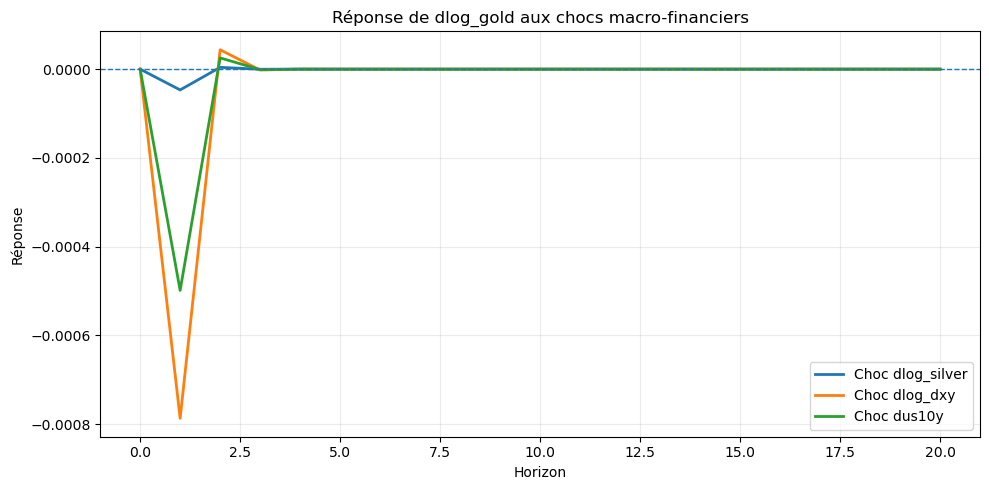

In [122]:
def plot_irf_clean(irf_obj, response, impulses, H=20, orth=True):
    irfs = irf_obj.orth_irfs if orth else irf_obj.irfs
    names = irf_obj.model.names
    response_idx = names.index(response)
    plt.figure(figsize=(10, 5))
    
    for impulse in impulses:
        impulse_idx = names.index(impulse)
        y = irfs[:H+1, response_idx, impulse_idx]

        plt.plot(range(H+1),y, linewidth=2, label=f"Choc {impulse}")
    
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"Réponse de {response} aux chocs macro-financiers")
    plt.xlabel("Horizon")
    plt.ylabel("Réponse")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

H = 20
irf_multi = final_var_multi.irf(H)

plot_irf_clean(irf_multi, response="dlog_gold", impulses=["dlog_silver", "dlog_dxy", "dus10y"], H=H, orth=True)

## 13. Synthèse économétrique

**Cadre bivarié or-argent** : la relation de cointégration entre les log-prix de l'or et de l'argent n'est pas stable sur l'ensemble de la période 2000-2024. 
Les tests globaux (Engle-Granger, Johansen) ne permettent pas de conclure à une cointégration robuste. 
L'analyse rolling révèle des épisodes ponctuels notamment autour de 2015-2016. 
Le VECM bivarié estimé sur cet épisode indique que l'argent est la variable d'ajustement (price follower) et l'or la variable directrice (price leader).

**Extension macro-financière** : l'introduction du dollar (DXY) et des taux à 10 ans (US10Y) dans le système enrichit le diagnostic. 
La cointégration est plus fréquente et plus longue en cadre multivarié. Cela confirme que le dollar et les taux sont des facteurs de pricing communs aux deux métaux.

**Hiérarchie causale** : les tests de Granger et de causalité instantanée montrent que le dollar et les taux exercent une causalité significative sur l'or tandis que l'or et l'argent entretiennent des liens contemporains forts.

Pour conclure, il n'existe pas d'équilibre permanent entre or et argent sur la période récente. La relation est conditionnelle au régime macrofinancier et se manifeste par épisodes sous la dépendance commune au dollar et aux taux réels américains.